# Summary

This notebook estimates the energy output of a wind turbine (80 m rotor, 1670 kW rated power) located in Sicily, using hourly historical wind speed and temperature data retrieved via API (Open-Meteo, 2019–2024). The pipeline converts wind speed into electrical output through two independent approaches — Betz's law, based on air density derived from the weather data, and interpolation of the manufacturer's power curve — before analyzing the resulting series (ADF stationarity test, additive/STL seasonal decomposition, linear regression) and producing forecasts of future production through three complementary methods: an ARIMA model fitted on the deseasonalized series, a Weibull distribution fit to wind speed, and a 100-path Monte Carlo simulation used to quantify forecast uncertainty over a 10-year horizon. The goal is to build a complete, reproducible empirical analysis — from data acquisition to statistical model validation — demonstrating skills in data engineering, time-series econometrics, and stochastic simulation applied to a real-world forecasting problem.

In [1]:
pip install openmeteo-requests


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install requests-cache retry-requests numpy pandas


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import requests_cache
import pandas as pd
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.seasonal import STL
from scipy.interpolate import interp1d
from matplotlib import pyplot as plt
from pmdarima.arima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from retry_requests import retry
from scipy.stats import weibull_min
import scipy.stats as stats
import matplotlib.dates as mdates
import openmeteo_requests
import seaborn as sns
import os
import pprint
import sklearn


In [6]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 37.4922,
	"longitude": 15.0704,
	"start_date": "2019-01-01",
	"end_date": "2024-01-01",
	"hourly": "wind_speed_100m",
	"wind_speed_unit": "ms"
}
responses = openmeteo.weather_api(url, params=params)

response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process hourly data
hourly = response.Hourly()
hourly_wind_speed_100m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}
hourly_data["wind_speed_100m"] = hourly_wind_speed_100m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print(hourly_dataframe)

Coordinates 37.504390716552734°N 15.09986686706543°E
Elevation 38.0 m asl
Timezone None None
Timezone difference to GMT+0 0 s
                           date  wind_speed_100m
0     2019-01-01 00:00:00+00:00         2.801785
1     2019-01-01 01:00:00+00:00         2.247221
2     2019-01-01 02:00:00+00:00         1.802776
3     2019-01-01 03:00:00+00:00         1.476482
4     2019-01-01 04:00:00+00:00         1.802776
...                         ...              ...
43843 2024-01-01 19:00:00+00:00         6.912307
43844 2024-01-01 20:00:00+00:00         7.580237
43845 2024-01-01 21:00:00+00:00         7.951101
43846 2024-01-01 22:00:00+00:00         9.144398
43847 2024-01-01 23:00:00+00:00         8.202438

[43848 rows x 2 columns]


In [7]:
# Setup of the client Open-Meteo API (cache and retry)
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Parameters for the request - SAME date range used for wind speed above,
# so the two hourly series line up row by row (the original code requested
# only 2023-2024, which silently desynchronised it from the wind series).
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 37.4922,
    "longitude": 15.0704,
    "start_date": "2019-01-01",
    "end_date": "2024-01-01",
    "hourly": "temperature_2m",
}

responses = openmeteo.weather_api(url, params=params)

response = responses[0]
print(f"Coordinate {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m s.l.m.")
print(f"Time zone {response.Timezone()} {response.TimezoneAbbreviation()}")

# Process hourly temperature data and convert Celsius -> Kelvin
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data_temp = {"date": pd.date_range(
    start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
    end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
    freq = pd.Timedelta(seconds = hourly.Interval()),
    inclusive = "left"
)}
hourly_data_temp["temperature_2m_kelvin"] = hourly_temperature_2m + 273.15

hourly_dataframe_temp_kelvin = pd.DataFrame(data = hourly_data_temp)
print(hourly_dataframe_temp_kelvin.head())


Coordinate 37.504390716552734°N 15.09986686706543°E
Elevation 38.0 m s.l.m.
Time zone None None
                       date  temperature_2m_kelvin
0 2019-01-01 00:00:00+00:00             280.850006
1 2019-01-01 01:00:00+00:00             280.149994
2 2019-01-01 02:00:00+00:00             279.049988
3 2019-01-01 03:00:00+00:00             277.500000
4 2019-01-01 04:00:00+00:00             277.250000


# Air density

In [8]:
def densita_aria(pressione, temperatura, altitudine):
    # Gas constant for dry air (J/(kg*K))
    R = 287.058
    # Corrected atmospheric pressure for the specific altitude, then density
    pressione_corretta = pressione * (1 - (0.0065 * altitudine) / temperatura) ** (-5.257)
    return pressione_corretta / (R * temperatura)

# Standard atmospheric pressure at sea level (Pa)
pressione_atmosferica_al_mare = 101325
altitudine_fissa = 100  # meters, turbine hub height

# The wind-speed and temperature series come from two separate API calls,
# so we align them explicitly on 'date' instead of assuming they already
# match row by row.
hourly_dataframe = hourly_dataframe.merge(
    hourly_dataframe_temp_kelvin, on='date', how='left'
)
hourly_dataframe['temperature_2m_kelvin'] = (
    hourly_dataframe['temperature_2m_kelvin'].ffill().bfill()
)

hourly_dataframe['densita_aria'] = densita_aria(
    pressione_atmosferica_al_mare,
    hourly_dataframe['temperature_2m_kelvin'],
    altitudine_fissa
)

print(hourly_dataframe.head())


                       date  wind_speed_100m  temperature_2m_kelvin  \
0 2019-01-01 00:00:00+00:00         2.801785             280.850006   
1 2019-01-01 01:00:00+00:00         2.247221             280.149994   
2 2019-01-01 02:00:00+00:00         1.802776             279.049988   
3 2019-01-01 03:00:00+00:00         1.476482             277.500000   
4 2019-01-01 04:00:00+00:00         1.802776             277.250000   

   densita_aria  
0      1.272221  
1      1.275439  
2      1.280528  
3      1.287769  
4      1.288944  


# Calcolo energia disponibile (formula di Betz)

In [9]:
print("Colonne presenti nel DataFrame:", hourly_dataframe.columns)

Colonne presenti nel DataFrame: Index(['date', 'wind_speed_100m', 'temperature_2m_kelvin', 'densita_aria'], dtype='object')


In [10]:
# Rotor diameter
diameter = 80  # meters
radius = diameter / 2
area = np.pi * radius**2  # area swept by the blades in square meters

# Maximum power coefficient according to Betz's law
Cp = 0.593

# Rated power of the system in kW
nominal_power_kW = 1670

# Function for calculating power based on Betz's law, with a limit on the rated power
def calculate_betz_power(row):
    wind_speed = row['wind_speed_100m']
    air_density = row['densita_aria']
    if wind_speed < 3:
        return 0
    power = 0.5 * air_density * area * wind_speed**3 * Cp
    power_kW = power / 1000  # Convert to kW
    return min(power_kW, nominal_power_kW)

# Apply the function to each row of the DataFrame
hourly_dataframe['betz_power_output_kW'] = hourly_dataframe.apply(calculate_betz_power, axis=1)

print(hourly_dataframe)


                           date  wind_speed_100m  temperature_2m_kelvin  \
0     2019-01-01 00:00:00+00:00         2.801785             280.850006   
1     2019-01-01 01:00:00+00:00         2.247221             280.149994   
2     2019-01-01 02:00:00+00:00         1.802776             279.049988   
3     2019-01-01 03:00:00+00:00         1.476482             277.500000   
4     2019-01-01 04:00:00+00:00         1.802776             277.250000   
...                         ...              ...                    ...   
43843 2024-01-01 19:00:00+00:00         6.912307             286.850006   
43844 2024-01-01 20:00:00+00:00         7.580237             286.799988   
43845 2024-01-01 21:00:00+00:00         7.951101             286.549988   
43846 2024-01-01 22:00:00+00:00         9.144398             286.299988   
43847 2024-01-01 23:00:00+00:00         8.202438             286.449982   

       densita_aria  betz_power_output_kW  
0          1.272221              0.000000  
1          

In [11]:
df_copia1 = hourly_dataframe.copy()

print("\nDataFrame copiato:")
print(df_copia1)


DataFrame copiato:
                           date  wind_speed_100m  temperature_2m_kelvin  \
0     2019-01-01 00:00:00+00:00         2.801785             280.850006   
1     2019-01-01 01:00:00+00:00         2.247221             280.149994   
2     2019-01-01 02:00:00+00:00         1.802776             279.049988   
3     2019-01-01 03:00:00+00:00         1.476482             277.500000   
4     2019-01-01 04:00:00+00:00         1.802776             277.250000   
...                         ...              ...                    ...   
43843 2024-01-01 19:00:00+00:00         6.912307             286.850006   
43844 2024-01-01 20:00:00+00:00         7.580237             286.799988   
43845 2024-01-01 21:00:00+00:00         7.951101             286.549988   
43846 2024-01-01 22:00:00+00:00         9.144398             286.299988   
43847 2024-01-01 23:00:00+00:00         8.202438             286.449982   

       densita_aria  betz_power_output_kW  
0          1.272221              0.

In [12]:
# Group by day and calculate the sum of the data for each day
somma_per_giorno = df_copia1.groupby(df_copia1['date'].dt.year).sum().astype(int)

print("Somma dei dati per ogni anno:")
print(somma_per_giorno)

Somma dei dati per ogni anno:
      wind_speed_100m  temperature_2m_kelvin  densita_aria  \
date                                                         
2019            39525                2555928         10729   
2020            34575                2562964         10757   
2021            40134                2558592         10717   
2022            36071                2559611         10713   
2023            36527                2559133         10715   
2024              117                   6882            29   

      betz_power_output_kW  
date                        
2019               3063943  
2020               2201892  
2021               3078115  
2022               2484289  
2023               2673067  
2024                  8160  


/var/folders/n8/b7r241zx32qbgtn38wlvvwl80000gn/T/ipykernel_26017/2052588429.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  somma_per_giorno = df_copia1.groupby(df_copia1['date'].dt.year).sum().astype(int)


# Power Curve Interpolation and Production Calculation

In [13]:
# Power curve data (wind speed in m/s, power output in kW)
power_curve = [
    (3, 15), (3.5, 31), (4, 64), (4.5, 96), (5, 146), (5.5, 196), (6, 267), (6.5, 344), (7, 443), (7.5, 546),
    (8, 678), (8.5, 809), (9, 967), (9.5, 1124), (10, 1296), (10.5, 1468), (11, 1560), (11.5, 1619), (12, 1660),
    (12.5, 1670), (13, 1670), (13.5, 1670), (14, 1670), (14.5, 1670), (15, 1670), (15.5, 1670), (16, 1670),
    (16.5, 1670), (17, 1600), (17.5, 1529), (18, 1474), (18.5, 1419), (19, 1364), (19.5, 1308), (20, 1253),
    (20.5, 1198), (21, 1143), (21.5, 1087), (22, 1032), (22.5, 976), (23, 921), (23.5, 866), (24, 810),
    (24.5, 755), (25, 702)
]

wind_speeds, powers = zip(*power_curve)

# Interpolation function for the power curve
power_interpolation = interp1d(wind_speeds, powers, bounds_error=False, fill_value=(0, powers[-1]))

# Function to calculate power based on wind speed using the interpolated power curve
def calculate_power(wind_speed):
    if wind_speed < 3:
        return 0
    return power_interpolation(wind_speed)

hourly_dataframe['power_output_kW'] = hourly_dataframe['wind_speed_100m'].apply(calculate_power)

print(hourly_dataframe)

                           date  wind_speed_100m  temperature_2m_kelvin  \
0     2019-01-01 00:00:00+00:00         2.801785             280.850006   
1     2019-01-01 01:00:00+00:00         2.247221             280.149994   
2     2019-01-01 02:00:00+00:00         1.802776             279.049988   
3     2019-01-01 03:00:00+00:00         1.476482             277.500000   
4     2019-01-01 04:00:00+00:00         1.802776             277.250000   
...                         ...              ...                    ...   
43843 2024-01-01 19:00:00+00:00         6.912307             286.850006   
43844 2024-01-01 20:00:00+00:00         7.580237             286.799988   
43845 2024-01-01 21:00:00+00:00         7.951101             286.549988   
43846 2024-01-01 22:00:00+00:00         9.144398             286.299988   
43847 2024-01-01 23:00:00+00:00         8.202438             286.449982   

       densita_aria  betz_power_output_kW  power_output_kW  
0          1.272221              0.000

In [14]:
df_copia = hourly_dataframe.copy()

print("\nDataFrame copiato:")
print(df_copia)


DataFrame copiato:
                           date  wind_speed_100m  temperature_2m_kelvin  \
0     2019-01-01 00:00:00+00:00         2.801785             280.850006   
1     2019-01-01 01:00:00+00:00         2.247221             280.149994   
2     2019-01-01 02:00:00+00:00         1.802776             279.049988   
3     2019-01-01 03:00:00+00:00         1.476482             277.500000   
4     2019-01-01 04:00:00+00:00         1.802776             277.250000   
...                         ...              ...                    ...   
43843 2024-01-01 19:00:00+00:00         6.912307             286.850006   
43844 2024-01-01 20:00:00+00:00         7.580237             286.799988   
43845 2024-01-01 21:00:00+00:00         7.951101             286.549988   
43846 2024-01-01 22:00:00+00:00         9.144398             286.299988   
43847 2024-01-01 23:00:00+00:00         8.202438             286.449982   

       densita_aria  betz_power_output_kW  power_output_kW  
0          1.27222

In [15]:
mean = hourly_dataframe['wind_speed_100m'].mean()

print(mean)

4.263652


In [16]:
# Drop columns
colonne_da_elim = ['wind_speed_100m']
df_copia = df_copia.drop(columns=colonne_da_elim)

print("DataFrame con le colonne eliminate:")
print(df_copia)


DataFrame con le colonne eliminate:
                           date  temperature_2m_kelvin  densita_aria  \
0     2019-01-01 00:00:00+00:00             280.850006      1.272221   
1     2019-01-01 01:00:00+00:00             280.149994      1.275439   
2     2019-01-01 02:00:00+00:00             279.049988      1.280528   
3     2019-01-01 03:00:00+00:00             277.500000      1.287769   
4     2019-01-01 04:00:00+00:00             277.250000      1.288944   
...                         ...                    ...           ...   
43843 2024-01-01 19:00:00+00:00             286.850006      1.245293   
43844 2024-01-01 20:00:00+00:00             286.799988      1.245513   
43845 2024-01-01 21:00:00+00:00             286.549988      1.246612   
43846 2024-01-01 22:00:00+00:00             286.299988      1.247714   
43847 2024-01-01 23:00:00+00:00             286.449982      1.247052   

       betz_power_output_kW  power_output_kW  
0                  0.000000         0.000000  
1    

In [17]:
# Group by year and calculate the sum of the data for each year
somma_per_anno = df_copia.groupby(df_copia['date'].dt.year).sum().astype(int)

print("Somma dei dati per ogni anno:")
print(somma_per_anno)

Somma dei dati per ogni anno:
      temperature_2m_kelvin  densita_aria  betz_power_output_kW  \
date                                                              
2019                2555928         10729               3063943   
2020                2562964         10757               2201892   
2021                2558592         10717               3078115   
2022                2559611         10713               2484289   
2023                2559133         10715               2673067   
2024                   6882            29                  8160   

      power_output_kW  
date                   
2019          2315265  
2020          1588093  
2021          2320176  
2022          1866335  
2023          2032587  
2024             5471  


/var/folders/n8/b7r241zx32qbgtn38wlvvwl80000gn/T/ipykernel_26017/3058368295.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  somma_per_anno = df_copia.groupby(df_copia['date'].dt.year).sum().astype(int)


# Statistical Measures for Time Series

In [18]:
import pandas as pd

mean_power_curve = hourly_dataframe['power_output_kW'].mean()

# Variance
variance_power_curve = hourly_dataframe['power_output_kW'].var()

# Standard deviation
std_deviation_power_curve = hourly_dataframe['power_output_kW'].std()

# Kurtosis
kurtosis_power_curve = hourly_dataframe['power_output_kW'].kurtosis()

# Skewness
skewness_power_curve = hourly_dataframe['power_output_kW'].skew()

stats_df = pd.DataFrame({
    'Media': [mean_power_curve],
    'Varianza': [variance_power_curve],
    'Deviazione standard': [std_deviation_power_curve],
    'Curtosi': [kurtosis_power_curve],
    'Skewness': [skewness_power_curve]
})

stats_df


,Media,Varianza,Deviazione standard,Curtosi,Skewness
0,230.978179,166210.816753,407.689608,3.832663,2.17015


In [19]:
mean_betz = hourly_dataframe['betz_power_output_kW'].mean()

# Variance
variance_betz = hourly_dataframe['betz_power_output_kW'].var()

# Standard deviation
std_deviation_betz = hourly_dataframe['betz_power_output_kW'].std()

# Kurtosis
kurtosis_betz = hourly_dataframe['betz_power_output_kW'].kurtosis()

# Skewness
skewness_betz = hourly_dataframe['betz_power_output_kW'].skew()

stats_df = pd.DataFrame({
    'Media': [mean_betz],
    'Varianza': [variance_betz],
    'Deviazione standard': [std_deviation_betz],
    'Curtosi': [kurtosis_betz],
    'Skewness': [skewness_betz]
})

stats_df


,Media,Varianza,Deviazione standard,Curtosi,Skewness
0,308.097715,238671.27483,488.539942,2.069448,1.817452


# Augmented Dickey-Fuller (ADF) Test

In [20]:
hourly_dataframe['date'] = pd.to_datetime(hourly_dataframe['date'])
hourly_dataframe.set_index('date', drop=False, inplace=True)


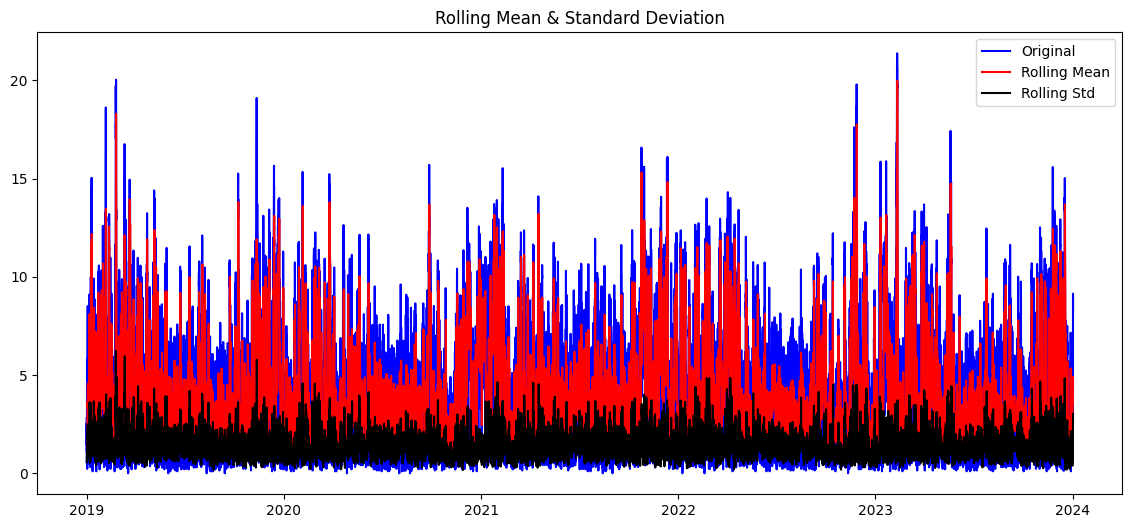

Results of Dickey-Fuller Test:
Test Statistic                   -20.375701
p-value                            0.000000
#Lags Used                        50.000000
Number of Observations Used    43797.000000
Critical Value (1%)               -3.430499
Critical Value (5%)               -2.861606
Critical Value (10%)              -2.566805
dtype: float64


In [21]:
def test_stationarity(timeseries):
    
    rolmean = timeseries.rolling(window=12).mean()
    rolstd = timeseries.rolling(window=12).std()

    
    plt.figure(figsize=(14, 6))
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    # Dickey-Fuller (ADF) Test
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

# Stationarity test
test_stationarity(hourly_dataframe['wind_speed_100m'])


# Seasonal component

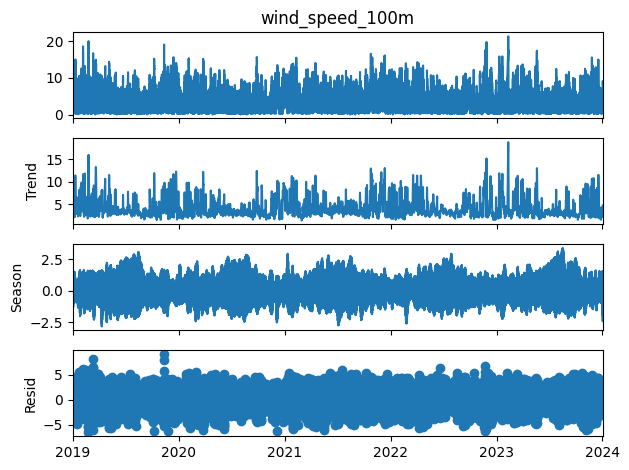

In [22]:
# Decomposition of the time series
stl = STL(hourly_dataframe['wind_speed_100m'], seasonal=13)
result = stl.fit()

# Plot the components
fig = result.plot()
plt.show()


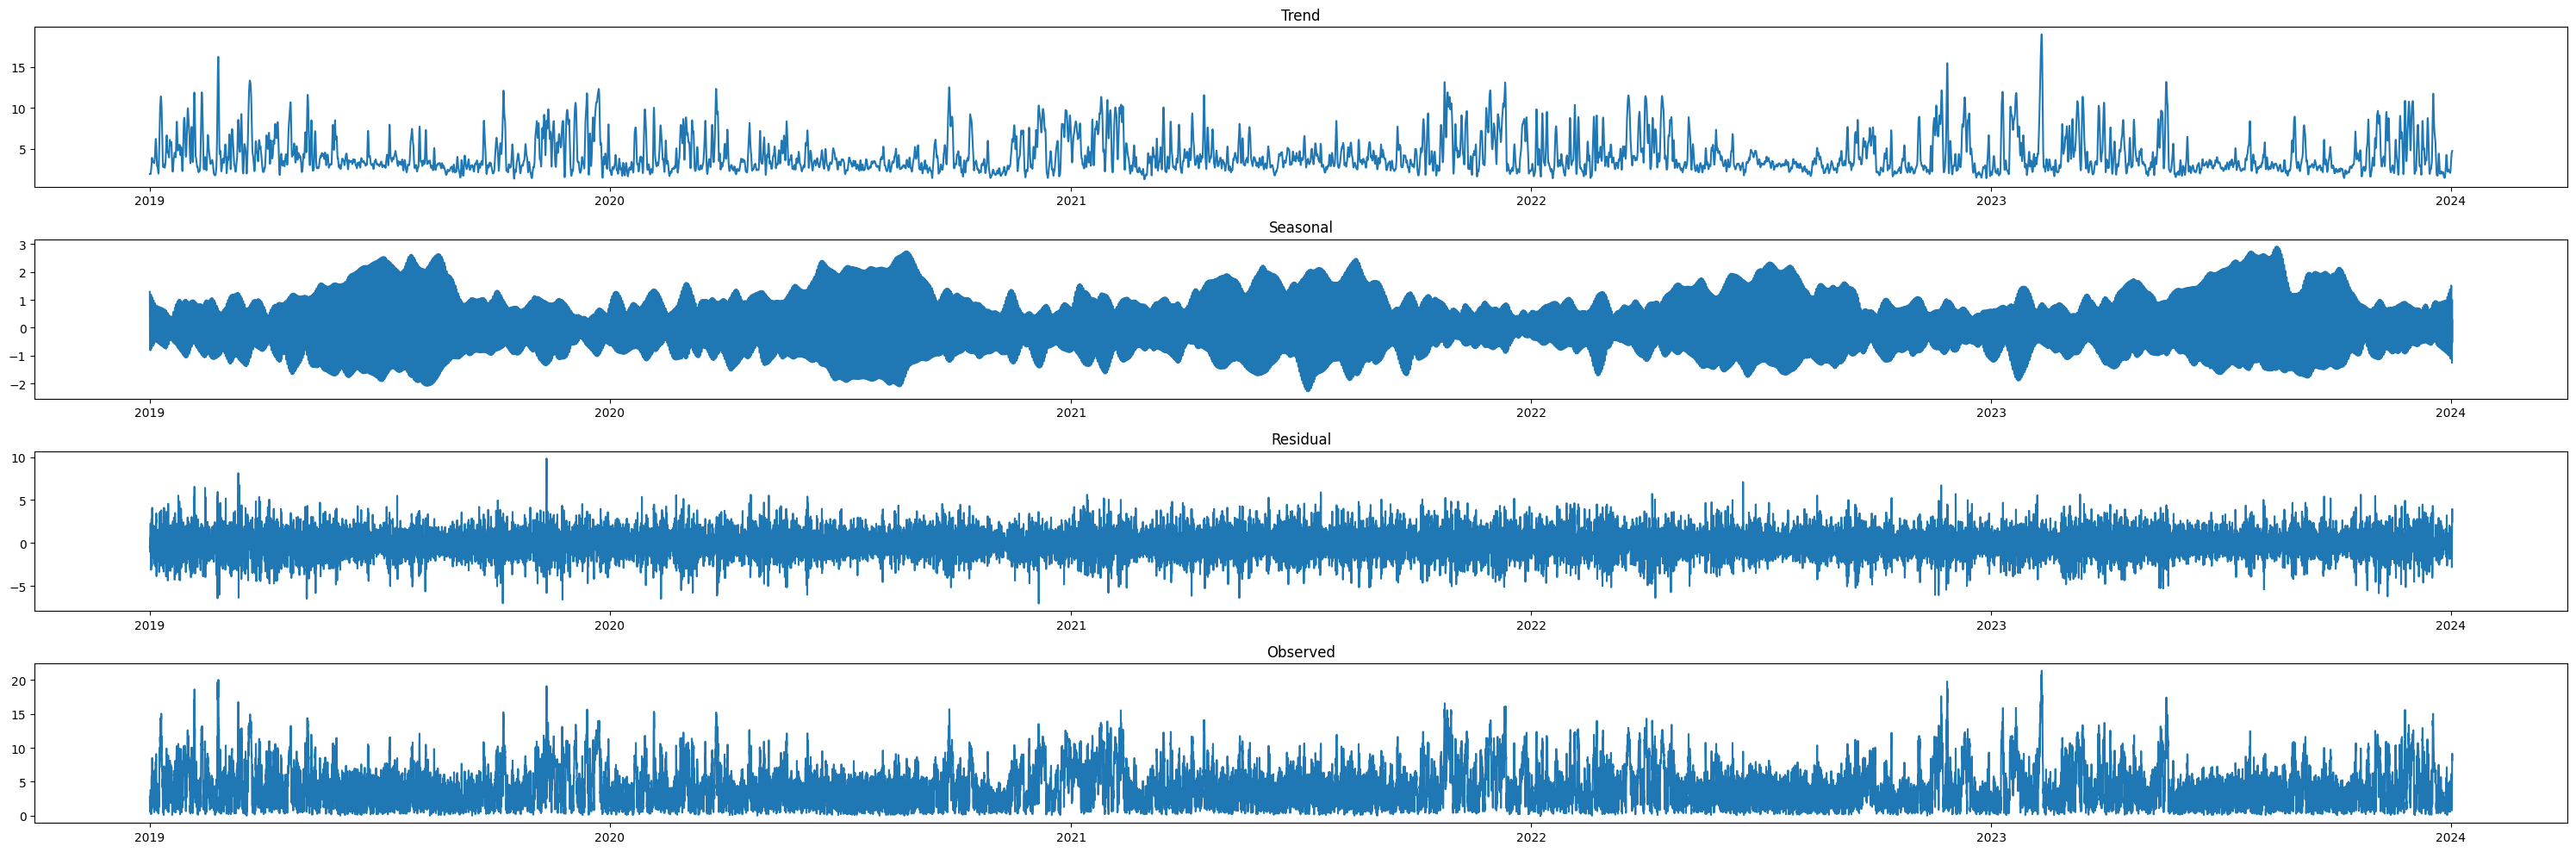

In [23]:
# Time series decomposition using STL
stl = STL(hourly_dataframe['wind_speed_100m'], seasonal=25)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(30, 10))

axes[0].plot(result.trend)
axes[0].set_title('Trend')
axes[1].plot(result.seasonal)
axes[1].set_title('Seasonal')
axes[2].plot(result.resid)
axes[2].set_title('Residual')
axes[3].plot(result.observed)
axes[3].set_title('Observed')

plt.tight_layout()

plt.show()


In [24]:
# Times series decomposition using seasonal_decompose
decomposition = seasonal_decompose(hourly_dataframe['wind_speed_100m'], model='additive', period=24)  # Ad esempio, periodo di 24 per dati orari con stagionalità giornaliera

detrended_series = hourly_dataframe['wind_speed_100m'] - decomposition.seasonal

In [25]:
detrended_df = detrended_series.to_frame()
detrended_df = detrended_series.to_frame(name='detrended_wind_value')
detrended_df.reset_index(inplace=True)

In [26]:
detrended_df

,date,detrended_wind_value
0,2019-01-01 00:00:00+00:00,2.807977
1,2019-01-01 01:00:00+00:00,2.162862
2,2019-01-01 02:00:00+00:00,1.699717
3,2019-01-01 03:00:00+00:00,1.435801
4,2019-01-01 04:00:00+00:00,1.857905
...,...,...
43843,2024-01-01 19:00:00+00:00,7.285837
43844,2024-01-01 20:00:00+00:00,7.978083
43845,2024-01-01 21:00:00+00:00,8.303020
43846,2024-01-01 22:00:00+00:00,9.375432


# ADF test 2

In [27]:
dataframe = hourly_dataframe

serie_temporale = dataframe['wind_speed_100m']

print('Risultati del Test di Dickey-Fuller:')
dftest = adfuller(serie_temporale)
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key, value in dftest[4].items():
    dfoutput['Critical Value (%s)' % key] = value
print(dfoutput)

Risultati del Test di Dickey-Fuller:
Test Statistic                   -20.375701
p-value                            0.000000
#Lags Used                        50.000000
Number of Observations Used    43797.000000
Critical Value (1%)               -3.430499
Critical Value (5%)               -2.861606
Critical Value (10%)              -2.566805
dtype: float64


In [29]:
train_percent = 0.7

train_size = int(len(detrended_series) * train_percent)

train_data_values = detrended_df.iloc[:train_size]['detrended_wind_value'].values
test_data_values = detrended_df.iloc[train_size:]['detrended_wind_value'].values

# Auto_ARIMA model selection
model = auto_arima(train_data_values, seasonal=False, suppress_warnings=True)

# Train the model using the selected parameters
result = model.fit(train_data_values)


KeyboardInterrupt



In [ ]:
print("Ordine del modello ARIMA:", result.order)

Ordine del modello ARIMA: (4, 1, 4)


# Seasonal and Trend decomposition using Losses

In [30]:
df_copia_STL = hourly_dataframe.copy()

print("\nDataFrame copiato:")
print(df_copia_STL)


DataFrame copiato:
                                               date  wind_speed_100m  \
date                                                                   
2019-01-01 00:00:00+00:00 2019-01-01 00:00:00+00:00         2.801785   
2019-01-01 01:00:00+00:00 2019-01-01 01:00:00+00:00         2.247221   
2019-01-01 02:00:00+00:00 2019-01-01 02:00:00+00:00         1.802776   
2019-01-01 03:00:00+00:00 2019-01-01 03:00:00+00:00         1.476482   
2019-01-01 04:00:00+00:00 2019-01-01 04:00:00+00:00         1.802776   
...                                             ...              ...   
2024-01-01 19:00:00+00:00 2024-01-01 19:00:00+00:00         6.912307   
2024-01-01 20:00:00+00:00 2024-01-01 20:00:00+00:00         7.580237   
2024-01-01 21:00:00+00:00 2024-01-01 21:00:00+00:00         7.951101   
2024-01-01 22:00:00+00:00 2024-01-01 22:00:00+00:00         9.144398   
2024-01-01 23:00:00+00:00 2024-01-01 23:00:00+00:00         8.202438   

                           temperature_2m_k

In [31]:
df_copia_STL.reset_index(drop=True, inplace=True)


In [32]:
print(df_copia_STL.columns)

Index(['date', 'wind_speed_100m', 'temperature_2m_kelvin', 'densita_aria',
       'betz_power_output_kW', 'power_output_kW'],
      dtype='object')


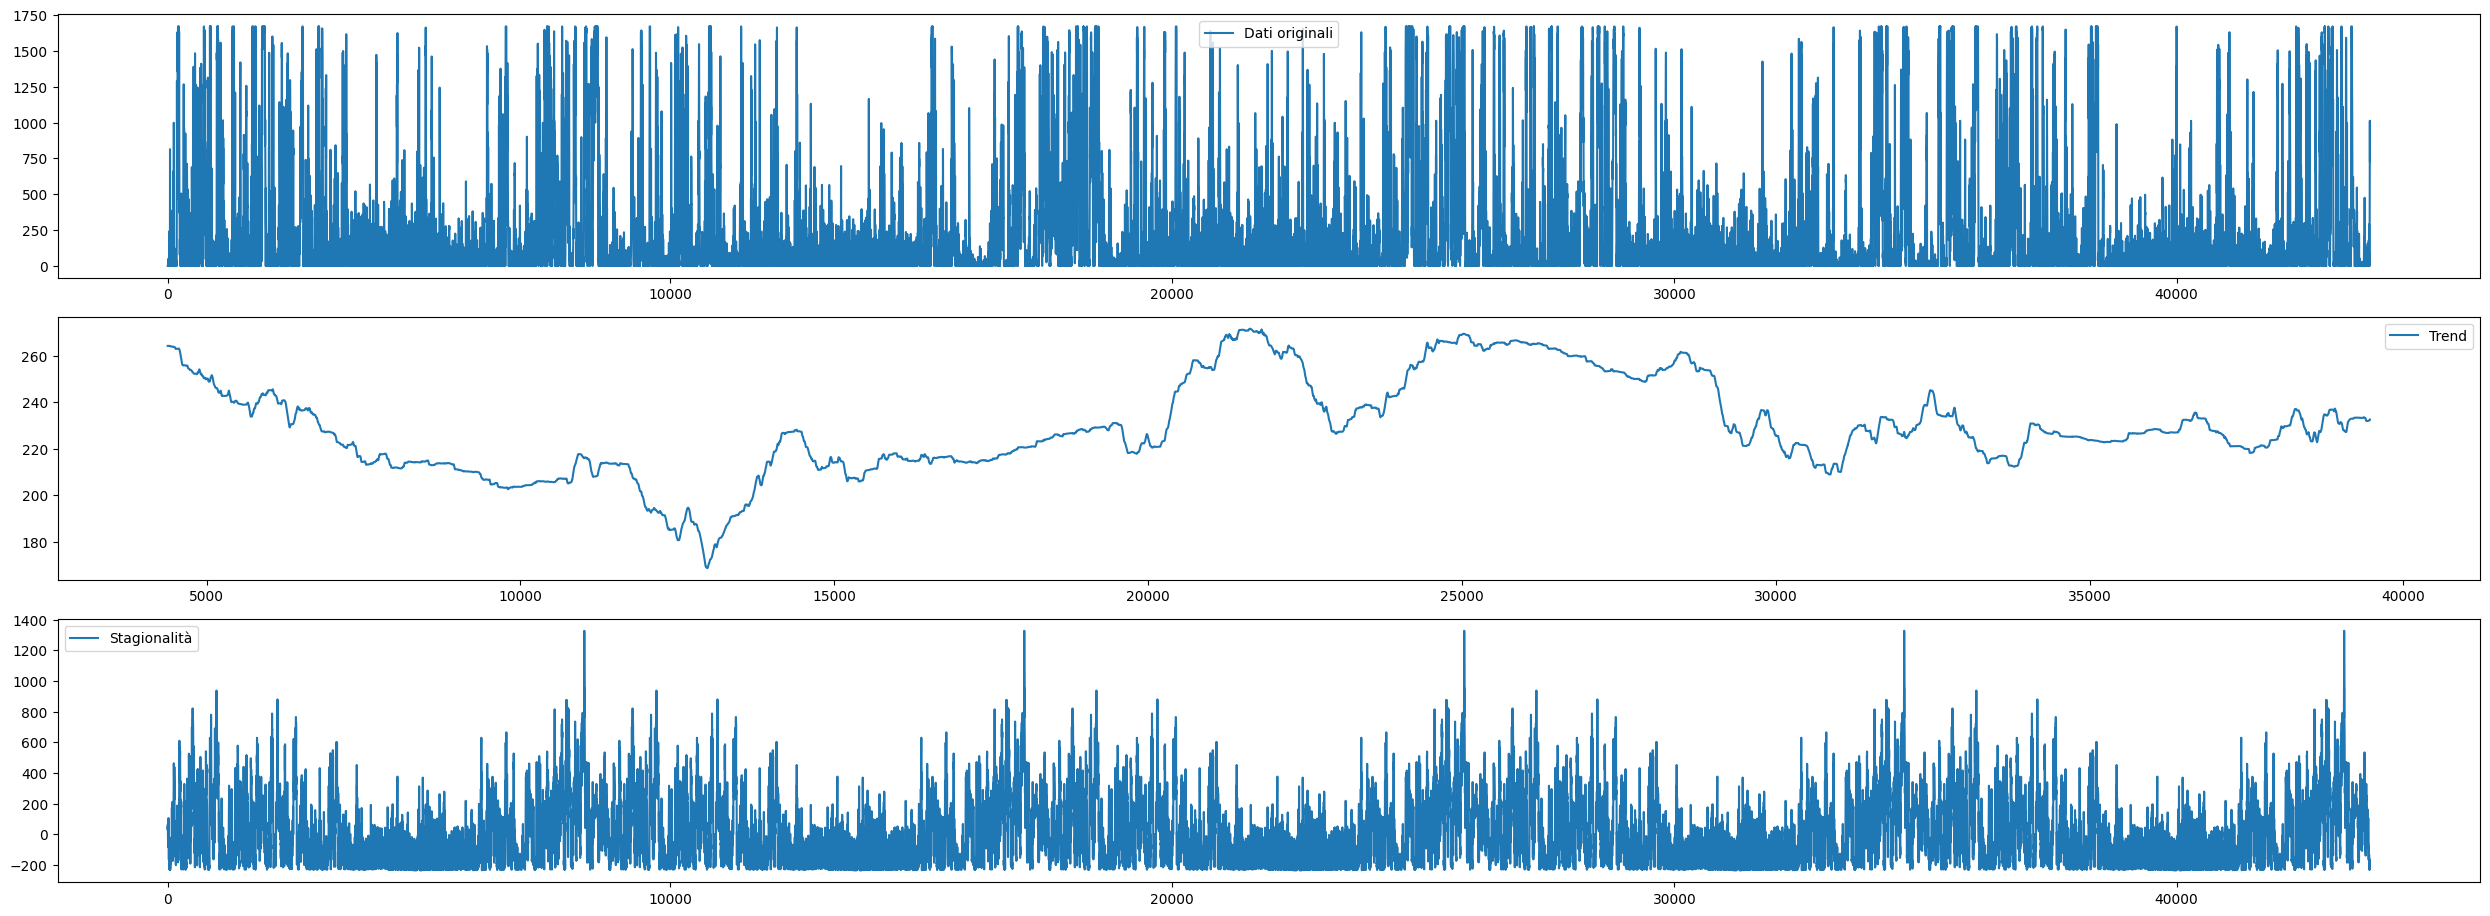

In [33]:
# STL decomposition
stl = seasonal_decompose(df_copia_STL['power_output_kW'], period=8760)  # period=24 per la stagionalità giornaliera (24 ore)

# Plot the decomposition
plt.figure(figsize=(25, 12))

plt.subplot(4, 1, 1)
plt.plot(df_copia_STL.index, df_copia_STL['power_output_kW'], label='Dati originali')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(stl.trend.index, stl.trend, label='Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(stl.seasonal.index, stl.seasonal, label='Stagionalità')
plt.legend()


plt.tight_layout()
plt.show()


In [34]:
# Seasonal decomposition
stl = seasonal_decompose(df_copia_STL['power_output_kW'], period=8760)  # period=8760 per la stagionalità annuale (8760 ore)

original_data = df_copia_STL['power_output_kW']

# Seasonal component
seasonal_component = stl.seasonal

data_without_seasonality = original_data - seasonal_component


In [35]:
original_data

0           0.000000
1           0.000000
2           0.000000
3           0.000000
4           0.000000
            ...     
43843     425.636838
43844     567.182671
43845     665.090618
43846    1012.340889
43847     731.038849
Name: power_output_kW, Length: 43848, dtype: float64

In [36]:
seasonal_component

0         47.041764
1         29.758956
2         64.766550
3         29.312517
4         18.772047
            ...    
43843   -229.427109
43844   -224.825550
43845   -220.950638
43846   -213.345492
43847   -182.619670
Name: seasonal, Length: 43848, dtype: float64

In [37]:
df_data_without_seasonality = pd.DataFrame(data_without_seasonality)

In [38]:
df_data_without_seasonality['date'] = hourly_dataframe['date'].dt.tz_localize(None).values

nome_file = "df_data_without_seasonality.xlsx"
df_data_without_seasonality.to_excel(nome_file, index=False)
print(f"Il DataFrame e' stato salvato nel file '{nome_file}'")


Il DataFrame e' stato salvato nel file 'df_data_without_seasonality.xlsx'


# Graphs Plot

In [39]:
hourly_dataframe

,date,wind_speed_100m,temperature_2m_kelvin,densita_aria,betz_power_output_kW,power_output_kW
date,,,,,,
2019-01-01 00:00:00+00:00,2019-01-01 00:00:00+00:00,2.801785,280.850006,1.272221,0.000000,0.000000
2019-01-01 01:00:00+00:00,2019-01-01 01:00:00+00:00,2.247221,280.149994,1.275439,0.000000,0.000000
2019-01-01 02:00:00+00:00,2019-01-01 02:00:00+00:00,1.802776,279.049988,1.280528,0.000000,0.000000
2019-01-01 03:00:00+00:00,2019-01-01 03:00:00+00:00,1.476482,277.500000,1.287769,0.000000,0.000000
2019-01-01 04:00:00+00:00,2019-01-01 04:00:00+00:00,1.802776,277.250000,1.288944,0.000000,0.000000
...,...,...,...,...,...,...
2024-01-01 19:00:00+00:00,2024-01-01 19:00:00+00:00,6.912307,286.850006,1.245293,612.964112,425.636838
2024-01-01 20:00:00+00:00,2024-01-01 20:00:00+00:00,7.580237,286.799988,1.245513,808.520575,567.182671
2024-01-01 21:00:00+00:00,2024-01-01 21:00:00+00:00,7.951101,286.549988,1.246612,933.915709,665.090618


In [40]:
print(hourly_dataframe.columns)

Index(['date', 'wind_speed_100m', 'temperature_2m_kelvin', 'densita_aria',
       'betz_power_output_kW', 'power_output_kW'],
      dtype='object')


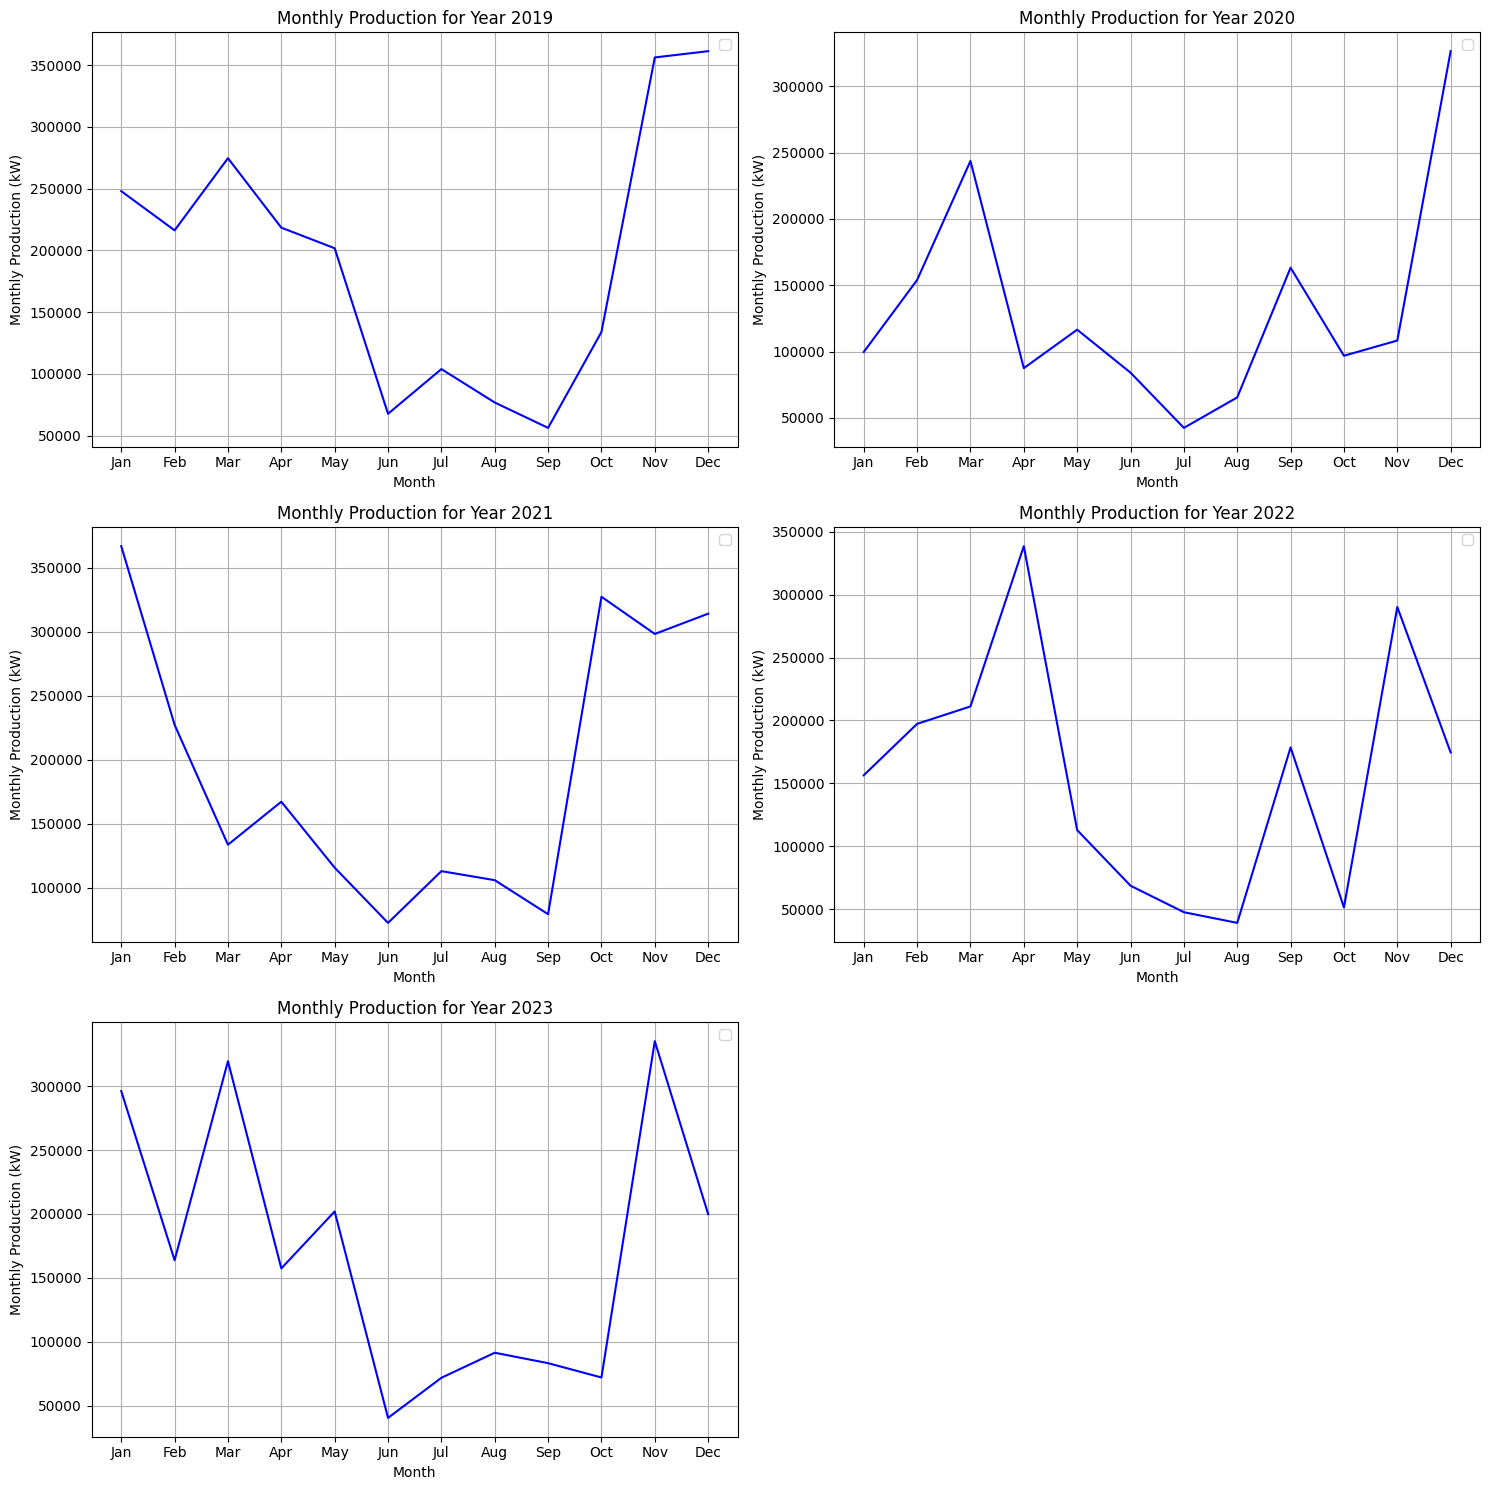

In [41]:
# Variable year
hourly_dataframe['year'] = hourly_dataframe['date'].dt.year

# Variable month
hourly_dataframe['month'] = hourly_dataframe['date'].dt.month

df_filtered = hourly_dataframe[hourly_dataframe['year'] != 2024]

# Sum the production by year and month
monthly_production = df_filtered.groupby(['year', 'month'])['power_output_kW'].sum()

monthly_production_kw = monthly_production  

# Plot
num_years = len(df_filtered['year'].unique())
num_cols = 2
num_rows = (num_years + num_cols - 1) // num_cols

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

for i, year in enumerate(df_filtered['year'].unique()):
    data_anno = monthly_production_kw.loc[year]
    ax = axs[i // num_cols, i % num_cols]
    ax.plot(data_anno.index.get_level_values('month'), data_anno.values, color='blue')
    
    ax.set_xlabel('Month')
    ax.set_ylabel('Monthly Production (kW)')
    ax.set_title(f'Monthly Production for Year {year}')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.legend([]) 
    
    
    ax.grid(True)


for i in range(num_years, num_rows * num_cols):
    fig.delaxes(axs.flatten()[i])

plt.tight_layout()
plt.show()


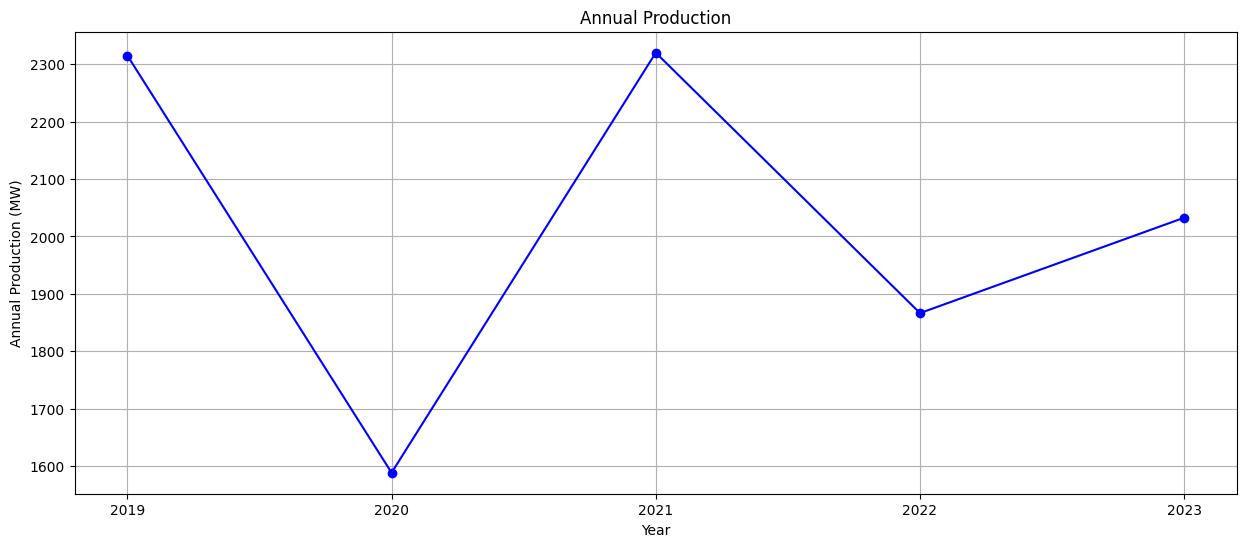

In [42]:
hourly_dataframe['year'] = hourly_dataframe['date'].dt.year

df_filtered = hourly_dataframe[hourly_dataframe['year'] != 2024]

annual_production = df_filtered.groupby('year')['power_output_kW'].sum()

# Watt to Kilowatt
annual_production_kw = annual_production/1000 

# Plot
plt.figure(figsize=(15, 6))
plt.plot(annual_production_kw.index, annual_production_kw.values, color='blue', marker='o')

plt.xlabel('Year')
plt.ylabel('Annual Production (MW)')
plt.title('Annual Production')
plt.grid(True)

plt.xticks(annual_production_kw.index)

plt.show()


# Weibull distribution

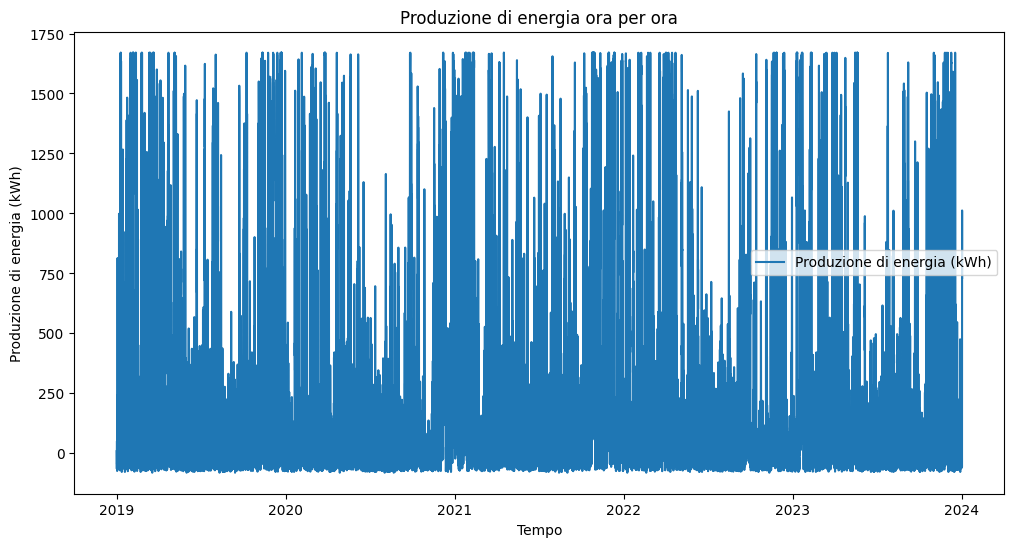

                                               date  wind_speed_100m  \
date                                                                   
2019-01-01 00:00:00+00:00 2019-01-01 00:00:00+00:00         2.801785   
2019-01-01 01:00:00+00:00 2019-01-01 01:00:00+00:00         2.247221   
2019-01-01 02:00:00+00:00 2019-01-01 02:00:00+00:00         1.802776   
2019-01-01 03:00:00+00:00 2019-01-01 03:00:00+00:00         1.476482   
2019-01-01 04:00:00+00:00 2019-01-01 04:00:00+00:00         1.802776   

                           temperature_2m_kelvin  densita_aria  \
date                                                             
2019-01-01 00:00:00+00:00             280.850006      1.272221   
2019-01-01 01:00:00+00:00             280.149994      1.275439   
2019-01-01 02:00:00+00:00             279.049988      1.280528   
2019-01-01 03:00:00+00:00             277.500000      1.287769   
2019-01-01 04:00:00+00:00             277.250000      1.288944   

                           betz_

In [43]:
# Power curve 
power_curve = [
    (3, 15), (3.5, 31), (4, 64), (4.5, 96), (5, 146), (5.5, 196), (6, 267), (6.5, 344), (7, 443), (7.5, 546),
    (8, 678), (8.5, 809), (9, 967), (9.5, 1124), (10, 1296), (10.5, 1468), (11, 1560), (11.5, 1619), (12, 1660),
    (12.5, 1670), (13, 1670), (13.5, 1670), (14, 1670), (14.5, 1670), (15, 1670), (15.5, 1670), (16, 1670),
    (16.5, 1670), (17, 1600), (17.5, 1529), (18, 1474), (18.5, 1419), (19, 1364), (19.5, 1308), (20, 1253),
    (20.5, 1198), (21, 1143), (21.5, 1087), (22, 1032), (22.5, 976), (23, 921), (23.5, 866), (24, 810),
    (24.5, 755), (25, 702)
]

velocities, powers = zip(*power_curve)

# Interpolation function
power_interpolation = interp1d(velocities, powers, kind='linear', fill_value="extrapolate")

wind_speeds = hourly_dataframe['wind_speed_100m']

hourly_dataframe['energy_produced'] = power_interpolation(wind_speeds)

plt.figure(figsize=(12, 6))
plt.plot(hourly_dataframe.index, hourly_dataframe['energy_produced'], label='Produzione di energia (kWh)')
plt.xlabel('Tempo')
plt.ylabel('Produzione di energia (kWh)')
plt.title('Produzione di energia ora per ora')
plt.legend()
plt.show()

print(hourly_dataframe.head())


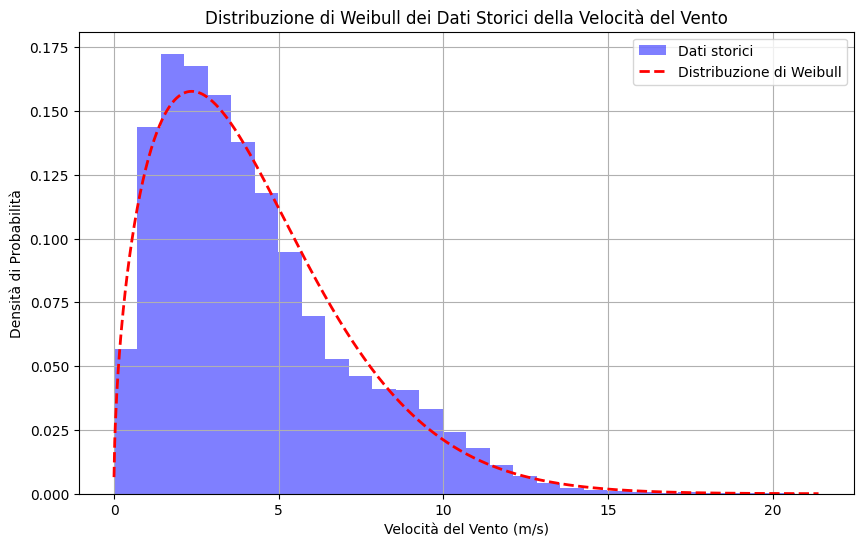

In [44]:
# Calculate the parameters of the Weibull distribution from historical wind speed data
shape, loc, scale = weibull_min.fit(hourly_dataframe['wind_speed_100m'])

x = np.linspace(0, hourly_dataframe['wind_speed_100m'].max(), 1000)

# Probability density function (PDF) of the Weibull distribution
pdf = weibull_min.pdf(x, shape, loc, scale)

plt.figure(figsize=(10, 6))
plt.hist(hourly_dataframe['wind_speed_100m'], bins=30, density=True, alpha=0.5, color='blue', label='Dati storici')
plt.plot(x, pdf, 'r--', linewidth=2, label='Distribuzione di Weibull')
plt.xlabel('Velocità del Vento (m/s)')
plt.ylabel('Densità di Probabilità')
plt.title('Distribuzione di Weibull dei Dati Storici della Velocità del Vento')
plt.legend()
plt.grid(True)
plt.show()


In [45]:
# The original cell tried to read 'df_seasonality.xlsx', a file this
# notebook never produced. We reuse the seasonal component already computed
# above (seasonal_decompose on power_output_kW) instead of depending on an
# external file that doesn't exist.
df_seasonality = pd.DataFrame({
    'date': df_copia_STL['date'],
    'seasonality': seasonal_component.values
})
print(df_seasonality.head())


                       date  seasonality
0 2019-01-01 00:00:00+00:00    47.041764
1 2019-01-01 01:00:00+00:00    29.758956
2 2019-01-01 02:00:00+00:00    64.766550
3 2019-01-01 03:00:00+00:00    29.312517
4 2019-01-01 04:00:00+00:00    18.772047


In [46]:
clean_production = pd.DataFrame()
clean_production['date'] = df_seasonality['date']

# hourly_dataframe is indexed by datetime while df_seasonality has a plain
# integer index, so we subtract by position (.values) rather than letting
# pandas align (and mostly fail) on mismatched index labels.
difference = hourly_dataframe['power_output_kW'].values - df_seasonality['seasonality'].values
difference[difference < 0] = 0

clean_production['power_production_kW_ns'] = difference
clean_production.columns


Index(['date', 'power_production_kW_ns'], dtype='object')

# Forecast (Weibull)

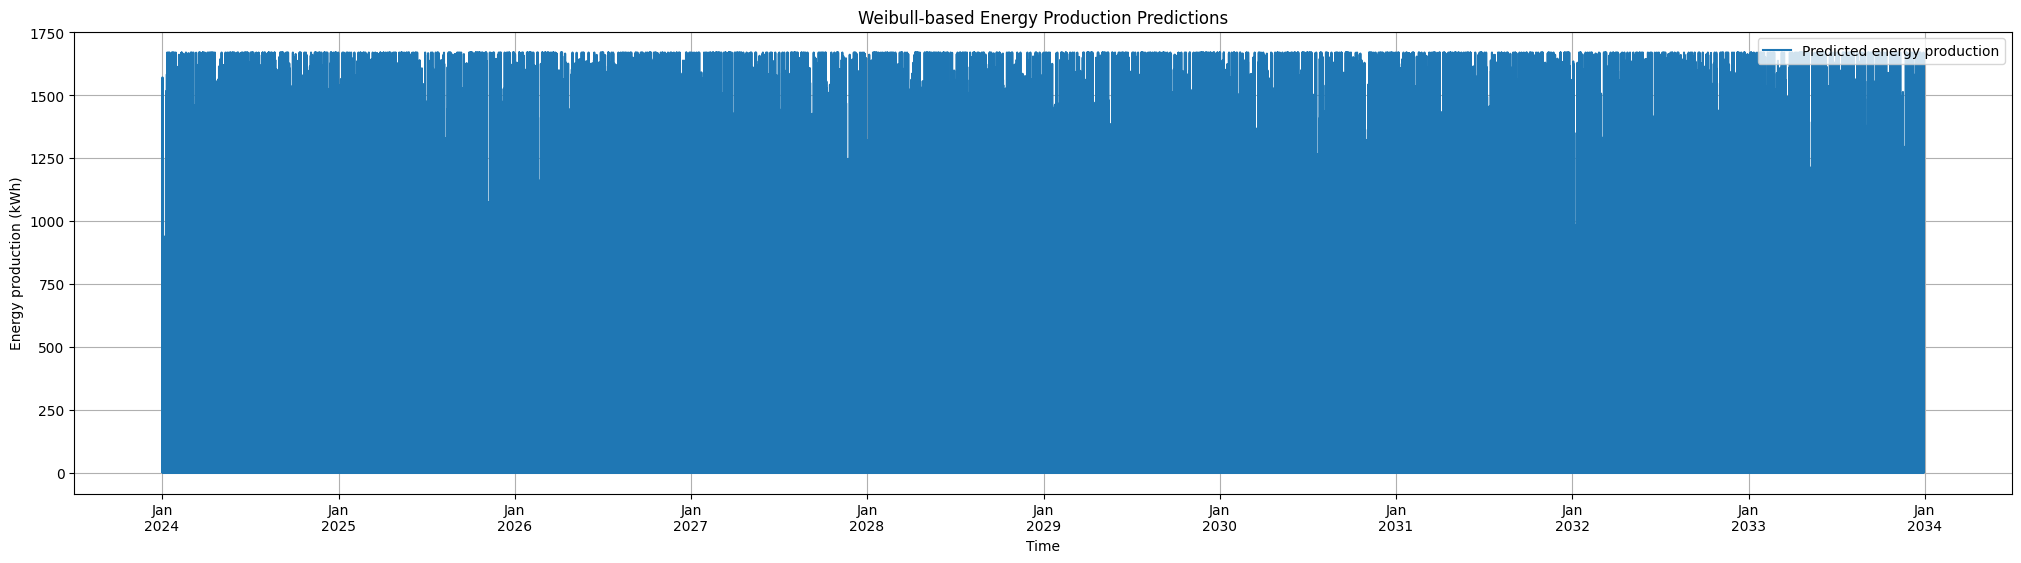

In [47]:
power_curve = [
    (3, 15), (3.5, 31), (4, 64), (4.5, 96), (5, 146), (5.5, 196), (6, 267), (6.5, 344), (7, 443), (7.5, 546),
    (8, 678), (8.5, 809), (9, 967), (9.5, 1124), (10, 1296), (10.5, 1468), (11, 1560), (11.5, 1619), (12, 1660),
    (12.5, 1670), (13, 1670), (13.5, 1670), (14, 1670), (14.5, 1670), (15, 1670), (15.5, 1670), (16, 1670),
    (16.5, 1670), (17, 1600), (17.5, 1529), (18, 1474), (18.5, 1419), (19, 1364), (19.5, 1308), (20, 1253),
    (20.5, 1198), (21, 1143), (21.5, 1087), (22, 1032), (22.5, 976), (23, 921), (23.5, 866), (24, 810),
    (24.5, 755), (25, 702)
]

velocities, powers = zip(*power_curve)

power_interpolation = interp1d(velocities, powers, kind='linear', fill_value="extrapolate")

shape, loc, scale = weibull_min.fit(hourly_dataframe['wind_speed_100m'])

# Forecast for the next 10 years (87600 hours)
numero_ore_previste = 87600 
future_wind_speeds = weibull_min.rvs(shape, loc=loc, scale=scale, size=numero_ore_previste)

future_energy_production = power_interpolation(future_wind_speeds)

# If the predicted energy production is negative, set it to zero
future_energy_production = np.maximum(future_energy_production, 0)

last_date = hourly_dataframe.index[-1]
future_dates = pd.date_range(start=last_date, periods=numero_ore_previste + 1, freq='H')[1:]

plt.figure(figsize=(25, 6))
plt.plot(future_dates, future_energy_production, label='Predicted energy production')
plt.xlabel('Time')
plt.ylabel('Energy production (kWh)')
plt.title('Weibull-based Energy Production Predictions')
plt.legend(loc='upper right')
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))  # Formattazione dei mesi e degli anni sull'asse x
plt.show()


In [48]:
predicted_energy_df = pd.DataFrame({'DateTime': future_dates, 'Predicted_Energy': future_energy_production})

print(predicted_energy_df.head())


                   DateTime  Predicted_Energy
0 2024-01-02 00:00:00+00:00         25.896571
1 2024-01-02 01:00:00+00:00       1571.115256
2 2024-01-02 02:00:00+00:00         42.398151
3 2024-01-02 03:00:00+00:00        650.963124
4 2024-01-02 04:00:00+00:00         86.459341


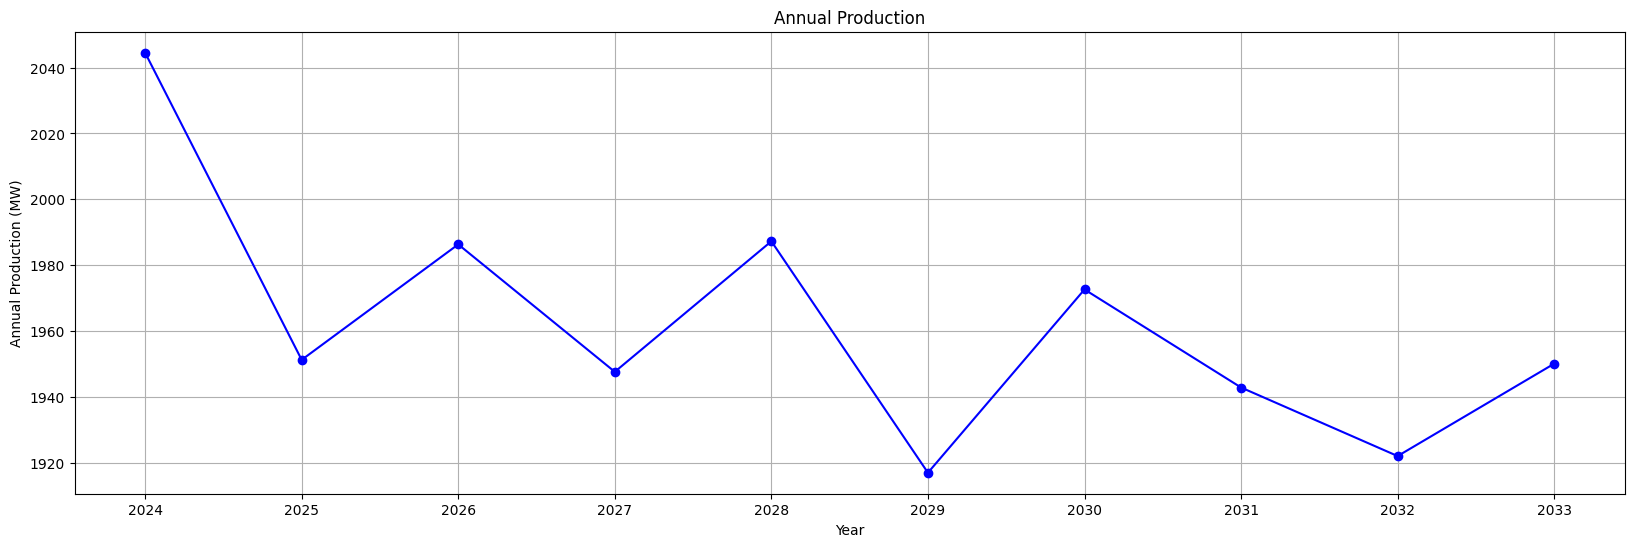

In [49]:
predicted_energy_df['year'] = predicted_energy_df['DateTime'].dt.year

df_filtered = predicted_energy_df

annual_production = df_filtered.groupby('year')['Predicted_Energy'].sum()

annual_production_kw = annual_production/1000 

plt.figure(figsize=(20, 6))
plt.plot(annual_production_kw.index, annual_production_kw.values, color='blue', marker='o')

plt.xlabel('Year')
plt.ylabel('Annual Production (MW)')
plt.title('Annual Production')
plt.grid(True)

plt.xticks(annual_production_kw.index)

plt.show()


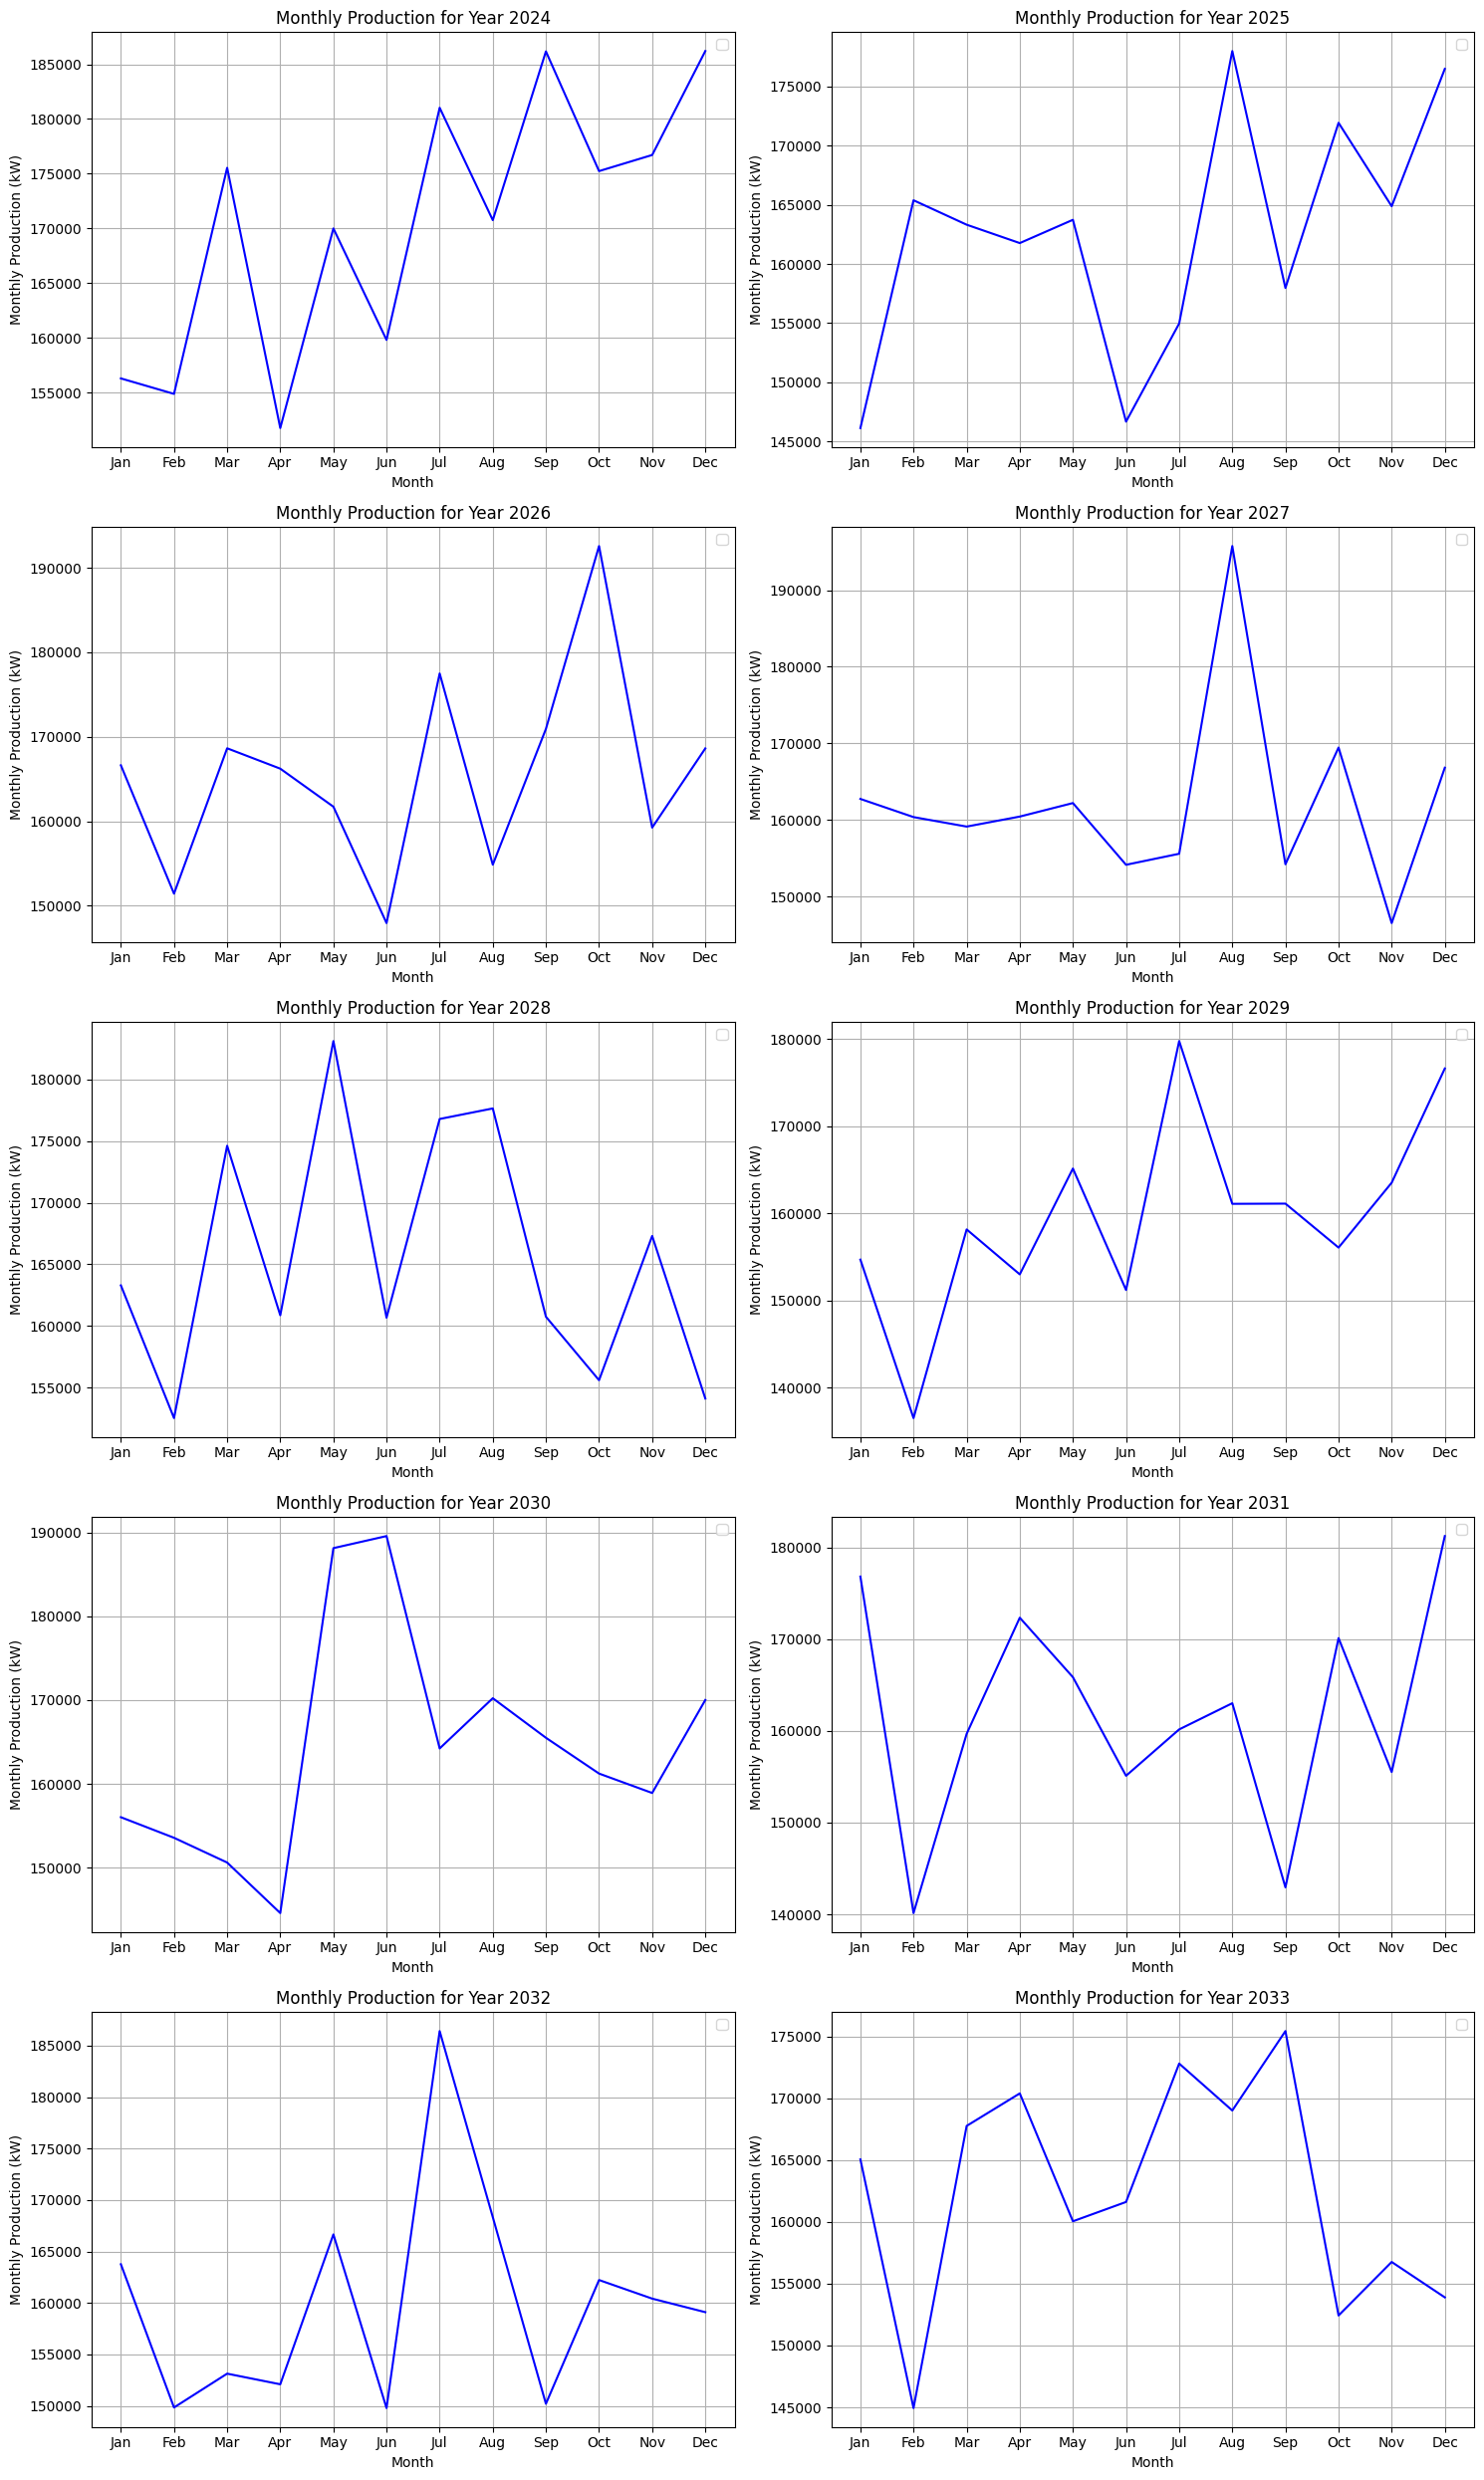

In [50]:
predicted_energy_df['year'] = predicted_energy_df['DateTime'].dt.year
predicted_energy_df['month'] = predicted_energy_df['DateTime'].dt.month
df_filtered = predicted_energy_df
monthly_production = df_filtered.groupby(['year', 'month'])['Predicted_Energy'].sum()


monthly_production_kw = monthly_production  

num_years = len(df_filtered['year'].unique())
num_cols = 2
num_rows = (num_years + num_cols - 1) // num_cols

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

for i, year in enumerate(df_filtered['year'].unique()):
    data_anno = monthly_production_kw.loc[year]
    ax = axs[i // num_cols, i % num_cols]
    ax.plot(data_anno.index.get_level_values('month'), data_anno.values, color='blue')
    
    ax.set_xlabel('Month')
    ax.set_ylabel('Monthly Production (kW)')
    ax.set_title(f'Monthly Production for Year {year}')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.legend([])
    
    ax.grid(True)

for i in range(num_years, num_rows * num_cols):
    fig.delaxes(axs.flatten()[i])

plt.tight_layout()
plt.show()


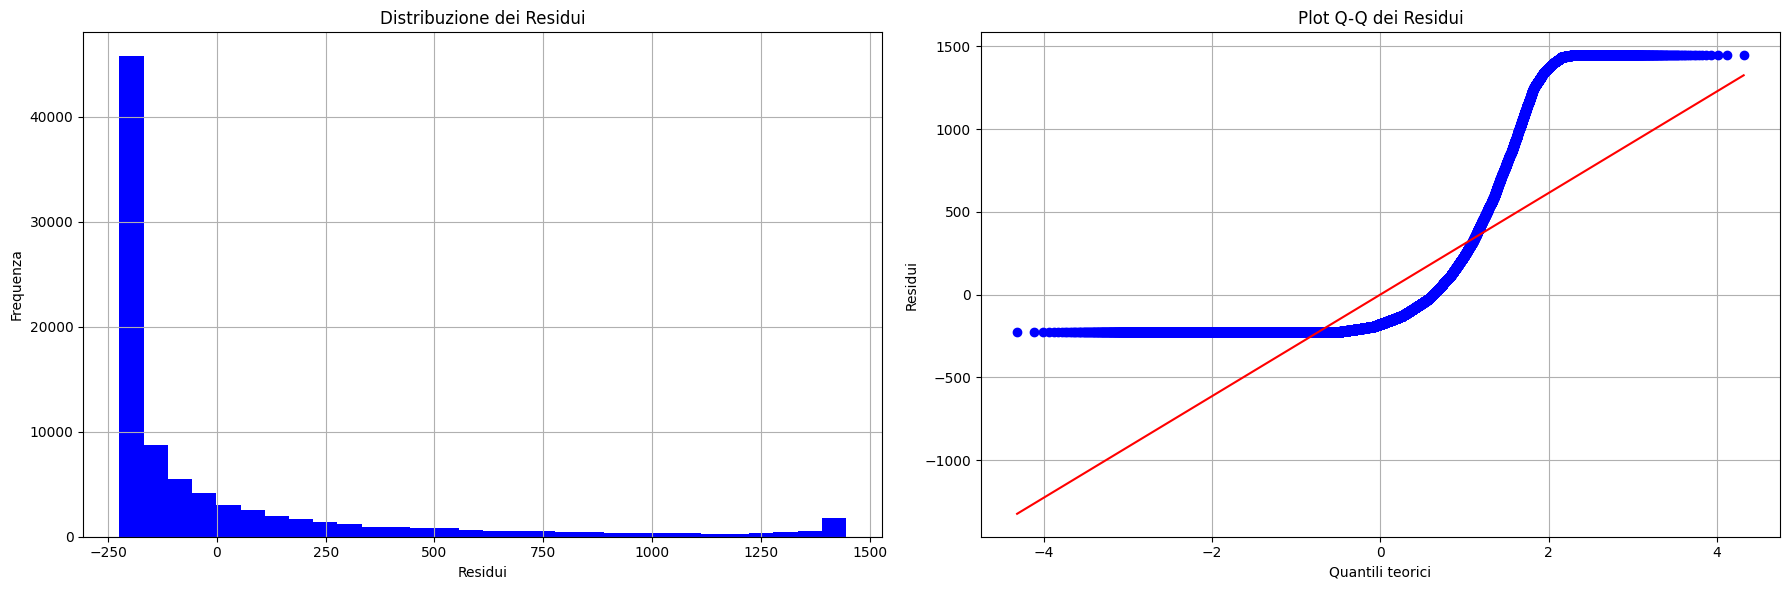

Test di Shapiro-Wilk per normalità dei residui:
Statistiche test: 0.6297131776809692
p-value: 0.0


/Users/lucianoconsoli/miniconda3/lib/python3.10/site-packages/scipy/stats/morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [51]:
# Residuals
residuals = future_energy_production - future_energy_production.mean()

#Residuals plot
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, color='blue', alpha=1)
plt.title('Distribuzione dei Residui')
plt.xlabel('Residui')
plt.ylabel('Frequenza')
plt.grid(True)

# Normal Q-Q plot of residuals
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Plot Q-Q dei Residui')
plt.xlabel('Quantili teorici')
plt.ylabel('Residui')
plt.grid(True)

plt.tight_layout()
plt.show()

# Shapiro-Wilk test for normality of residuals
shapiro_test = stats.shapiro(residuals)
print("Test di Shapiro-Wilk per normalità dei residui:")
print("Statistiche test:", shapiro_test[0])
print("p-value:", shapiro_test[1])


# Linear regression

In [52]:
wind_speed = hourly_dataframe['wind_speed_100m'].values
power_output = hourly_dataframe['power_output_kW'].values

# beta_0 and beta_1 are the parameters of the linear regression model
X = np.column_stack([np.ones_like(wind_speed), wind_speed])
beta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(power_output)

beta_0 = beta[0]  # beta_0
beta_1 = beta[1]  # beta_1

print("Coefficiente dell'intercetta (beta_0):", beta_0)
print("Coefficiente della velocità del vento (beta_1):", beta_1)


Coefficiente dell'intercetta (beta_0): -315.2179837096729
Coefficiente della velocità del vento (beta_1): 128.10520975397557


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

data = hourly_dataframe[['wind_speed_100m', 'power_output_kW']]

# Train/test split (80% train, 20% test): standard convention, uses most of
# the historical record to fit the model and holds out a meaningful sample
# for honest evaluation.
X = data[['wind_speed_100m']]  # Independent variable (wind speed)
y = data['power_output_kW']    # Dependent variable (power output)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training using linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the power output for the test set
y_pred = model.predict(X_test)

# Calculate the mean squared error (MSE) of the predictions
mse = mean_squared_error(y_test, y_pred)
print("Errore quadratico medio (MSE):", mse)


Errore quadratico medio (MSE): 27543.320155846333


In [54]:
y_pred_train = model.predict(X_train)

y_pred_test = model.predict(X_test)

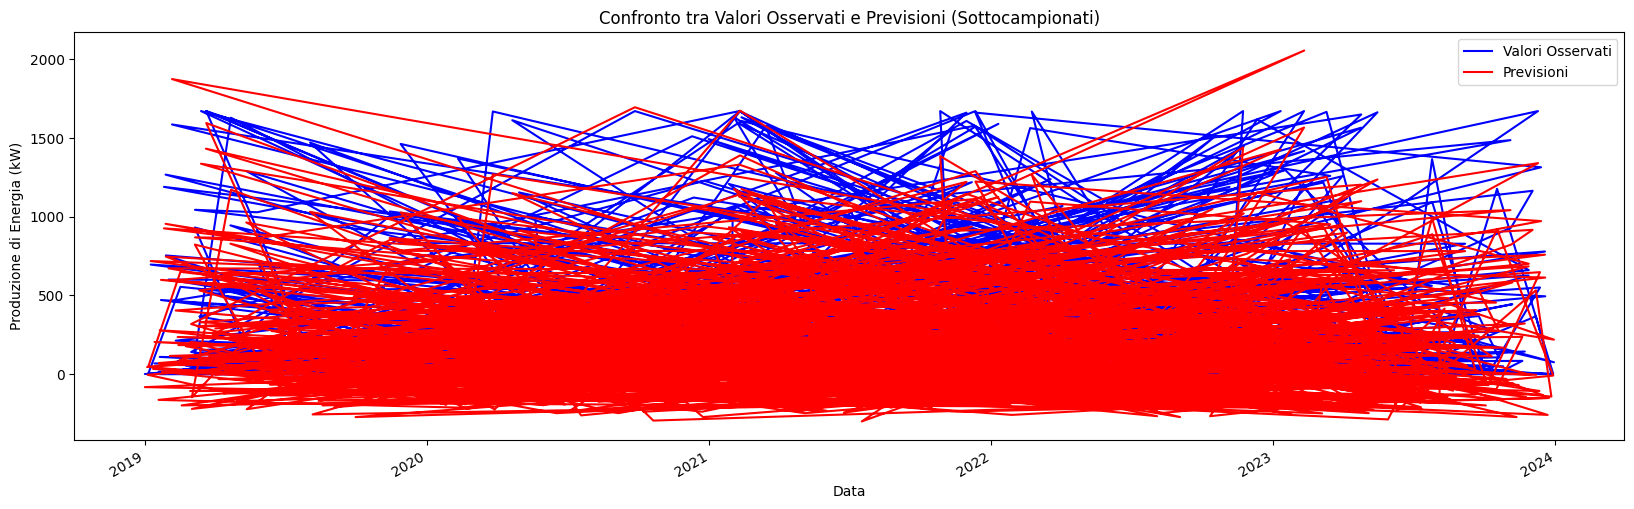

In [55]:
step = 10
hours = X_test.index  # datetime index of the held-out test observations
hours_subsampled = hours[::step]
y_test_subsampled = y_test.values[::step]
y_pred_test_subsampled = y_pred_test[::step]

plt.figure(figsize=(20, 6))
plt.plot(hours_subsampled, y_test_subsampled, label='Valori Osservati', color='blue')
plt.plot(hours_subsampled, y_pred_test_subsampled, label='Previsioni', color='red')

plt.xlabel('Data')
plt.ylabel('Produzione di Energia (kW)')
plt.title('Confronto tra Valori Osservati e Previsioni (Sottocampionati)')
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()


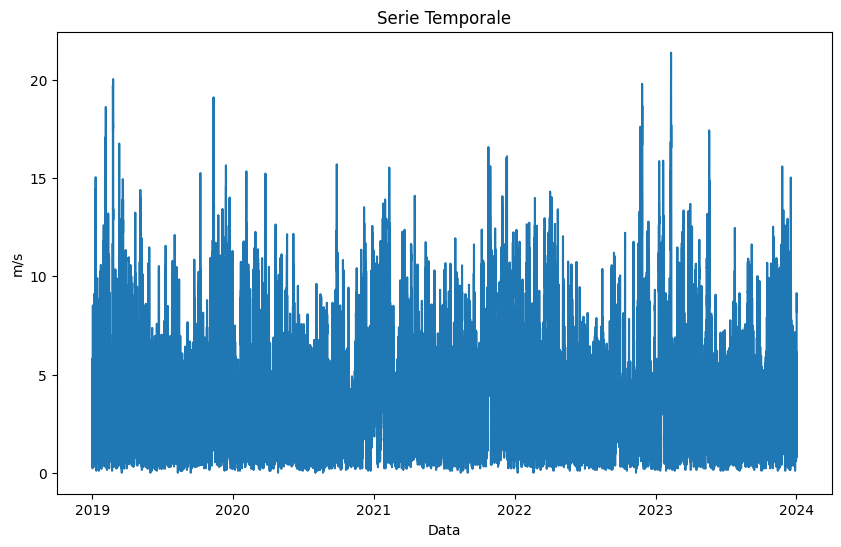

Statistiche del test Dickey-Fuller Aumentato:
Test Statistic: -20.375700682724773
Valore p: 0.0
Valori Critici:
	1%: -3.430
	5%: -2.862
	10%: -2.567


In [56]:
from statsmodels.tsa.stattools import adfuller

serie_temporale = hourly_dataframe['wind_speed_100m']

plt.figure(figsize=(10, 6))
plt.plot(serie_temporale)
plt.title('Serie Temporale')
plt.xlabel('Data')
plt.ylabel('m/s')
plt.show()

# Stationarity test using Augmented Dickey-Fuller (ADF) test
result = adfuller(serie_temporale)
print('Statistiche del test Dickey-Fuller Aumentato:')
print('Test Statistic:', result[0])
print('Valore p:', result[1])
print('Valori Critici:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))


# Forecast (Montecarlo method)

In [57]:
# Weibull parameters estimated directly from the historical wind-speed
# series (instead of hardcoded numbers copy-pasted from an earlier run),
# using the same weibull_min parametrization as the rest of the notebook.
shape, loc, scale = weibull_min.fit(hourly_dataframe['wind_speed_100m'])

ultima_data = hourly_dataframe['date'].iloc[-1]

# Length of the simulation in hours (10 years)
num_ore = 24 * 365 * 10  # 10 anni

# Monte Carlo simulation
num_percorsi = 100
monte_carlo_data = []

for _ in range(num_percorsi):
    simulazione = weibull_min.rvs(shape, loc=loc, scale=scale, size=num_ore)
    monte_carlo_data.append(simulazione)

date_range = pd.date_range(start=ultima_data, periods=num_ore + 1, freq='h')[1:]
monte_carlo_df = pd.DataFrame(index=date_range)

for i, simulazione in enumerate(monte_carlo_data, start=1):
    monte_carlo_df[f'Path_{i}'] = simulazione

print(monte_carlo_df.head())


                             Path_1    Path_2    Path_3    Path_4    Path_5  \
2024-01-02 00:00:00+00:00  4.291845  2.250914  2.181827  4.171733  3.230968   
2024-01-02 01:00:00+00:00  2.198043  3.272639  4.192197  3.544585  5.215687   
2024-01-02 02:00:00+00:00  4.275628  6.738787  9.531591  1.822265  2.736008   
2024-01-02 03:00:00+00:00  1.995805  5.223934  3.085360  7.107077  2.582817   
2024-01-02 04:00:00+00:00  2.951449  4.158124  5.726029  4.824863  3.819714   

                             Path_6    Path_7    Path_8    Path_9   Path_10  \
2024-01-02 00:00:00+00:00  2.195045  5.467842  7.322633  2.540856  2.523026   
2024-01-02 01:00:00+00:00  5.699326  0.397681  1.950276  0.610270  0.419572   
2024-01-02 02:00:00+00:00  3.466900  2.882081  1.992154  5.689640  7.315278   
2024-01-02 03:00:00+00:00  6.867758  5.790442  1.636209  5.565622  2.619870   
2024-01-02 04:00:00+00:00  1.308293  5.332138  1.827512  5.568389  4.724832   

                           ...    Path_91   Path_9

In [58]:
monte_carlo_df['Path_1'].var()

8.189442798774813

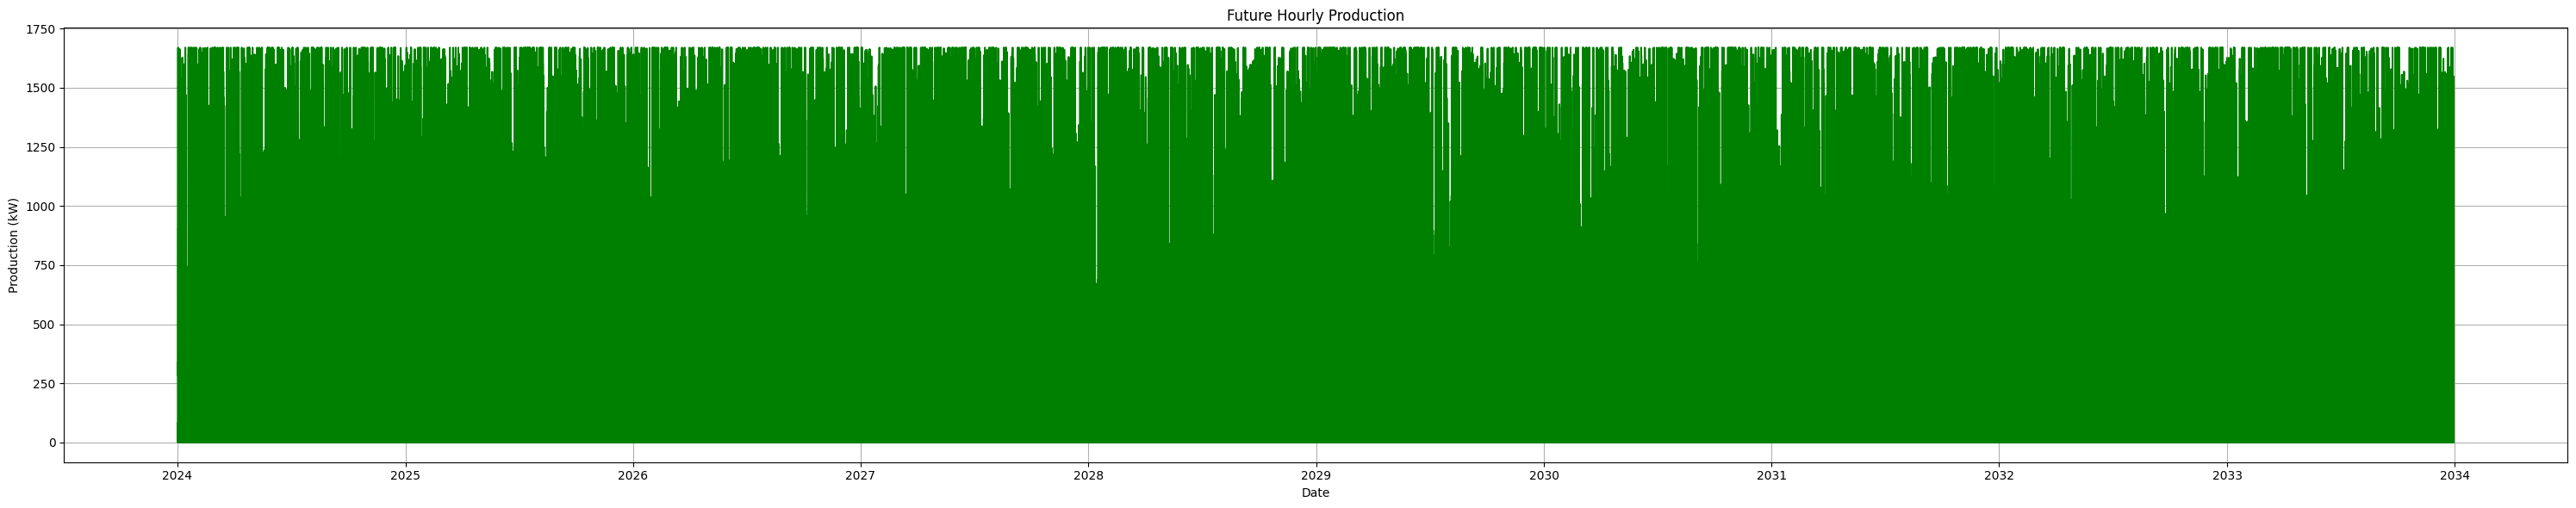

In [59]:
# Wind speed to power conversion using the interpolated power curve
produzione_futura_oraria = monte_carlo_df['Path_1'].apply(calculate_power)

plt.figure(figsize=(30, 6))
plt.plot(produzione_futura_oraria.index, produzione_futura_oraria, color='green')
plt.title('Future Hourly Production')
plt.xlabel('Date')
plt.ylabel('Production (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()

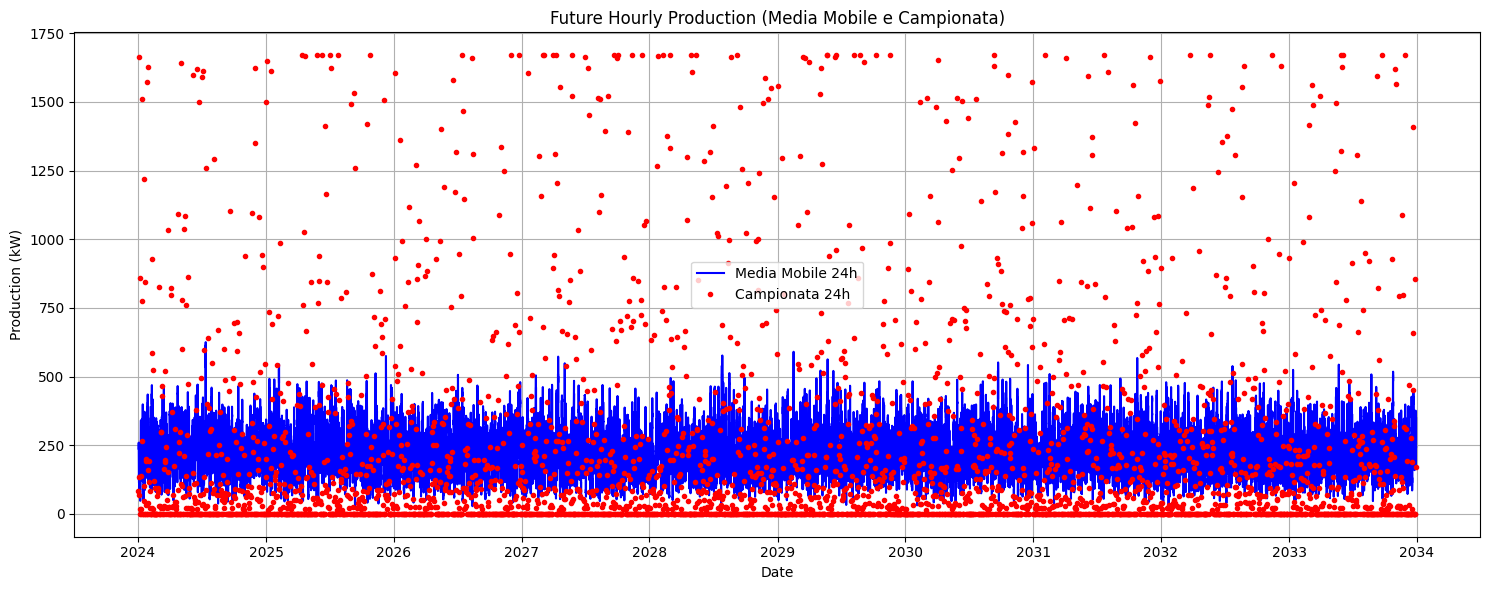

In [60]:
produzione_futura_oraria = monte_carlo_df['Path_1'].apply(calculate_power)

# Moving average of the future hourly production
produzione_futura_oraria_media_mobile = produzione_futura_oraria.rolling(window=24).mean()

# Subsample the future hourly production for plotting
produzione_futura_oraria_campionata = produzione_futura_oraria[::24]

plt.figure(figsize=(15, 6))
plt.plot(produzione_futura_oraria_media_mobile.index, produzione_futura_oraria_media_mobile, color='blue', label='Media Mobile 24h')
plt.plot(produzione_futura_oraria_campionata.index, produzione_futura_oraria_campionata, color='red', linestyle='None', marker='o', markersize=3, label='Campionata 24h')
plt.title('Future Hourly Production (Media Mobile e Campionata)')
plt.xlabel('Date')
plt.ylabel('Production (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
percorsi_stimati_subset = monte_carlo_df.sample(n=25, axis=1, random_state=42)

plt.figure(figsize=(25, 6))
for colonna in percorsi_stimati_subset.columns:
    plt.plot(percorsi_stimati_subset.index, percorsi_stimati_subset[colonna], label=colonna)

plt.title('Estimated Wind Speed Paths')
plt.xlabel('Date')
plt.ylabel('Wind speed m/s')
plt.grid(True)
plt.show()


In [ ]:
media_percorso = monte_carlo_df.mean(axis=1)

percorso_medio_df = pd.DataFrame({'Velocità Media del Vento': media_percorso}, index=monte_carlo_df.index)

print(percorso_medio_df)


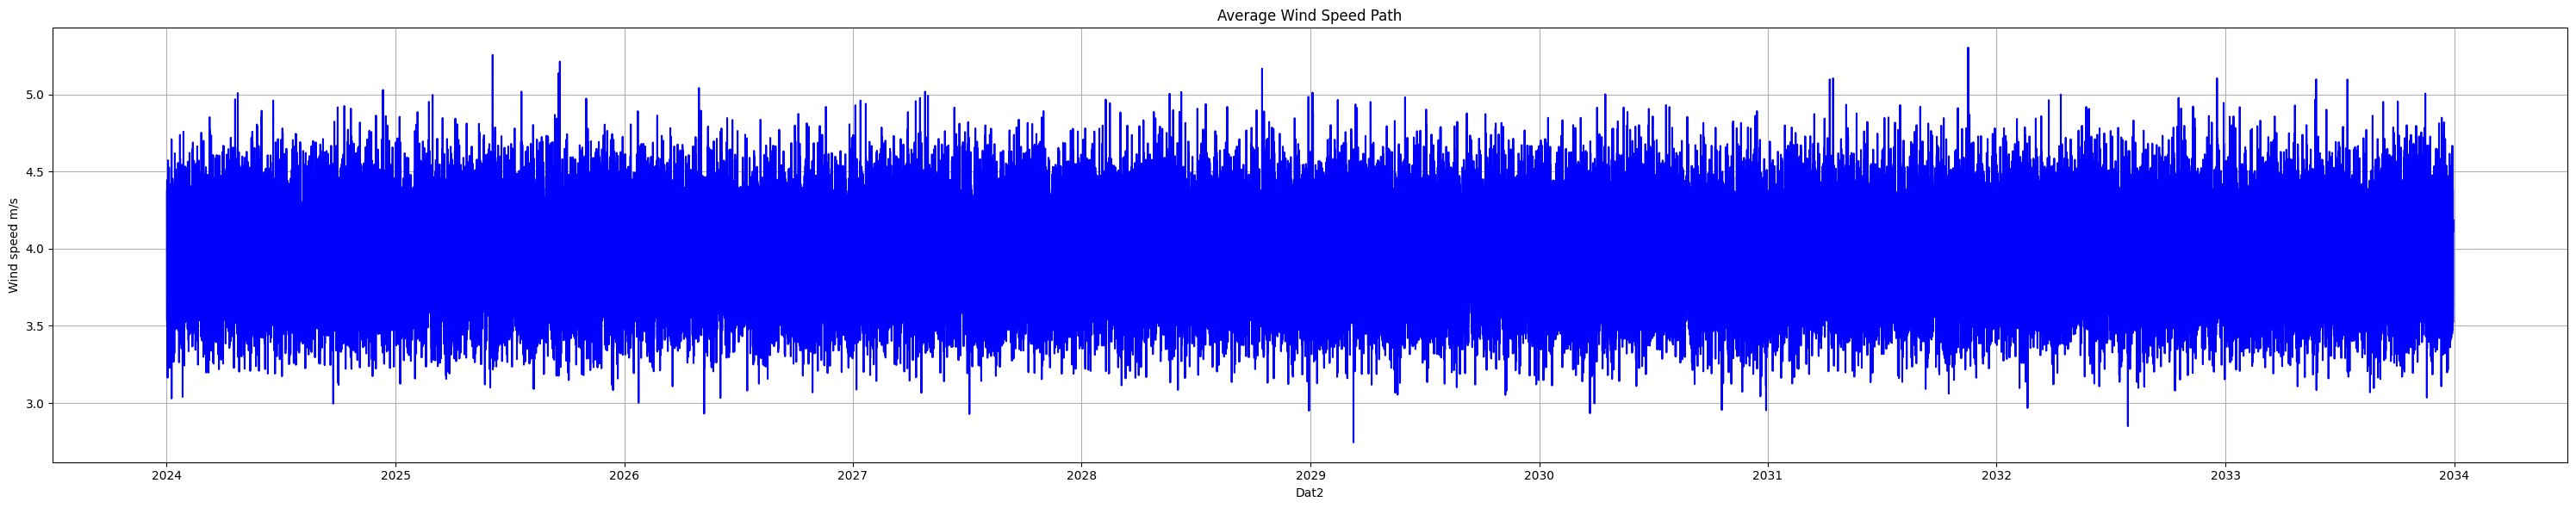

In [ ]:
plt.figure(figsize=(30, 6))
plt.plot(percorso_medio_df.index, percorso_medio_df['Velocità Media del Vento'], color='blue')

plt.title('Average Wind Speed Path')
plt.xlabel('Date')
plt.ylabel('Wind speed m/s')

# Mostrare il plot
plt.grid(True)
plt.tight_layout()
plt.show()


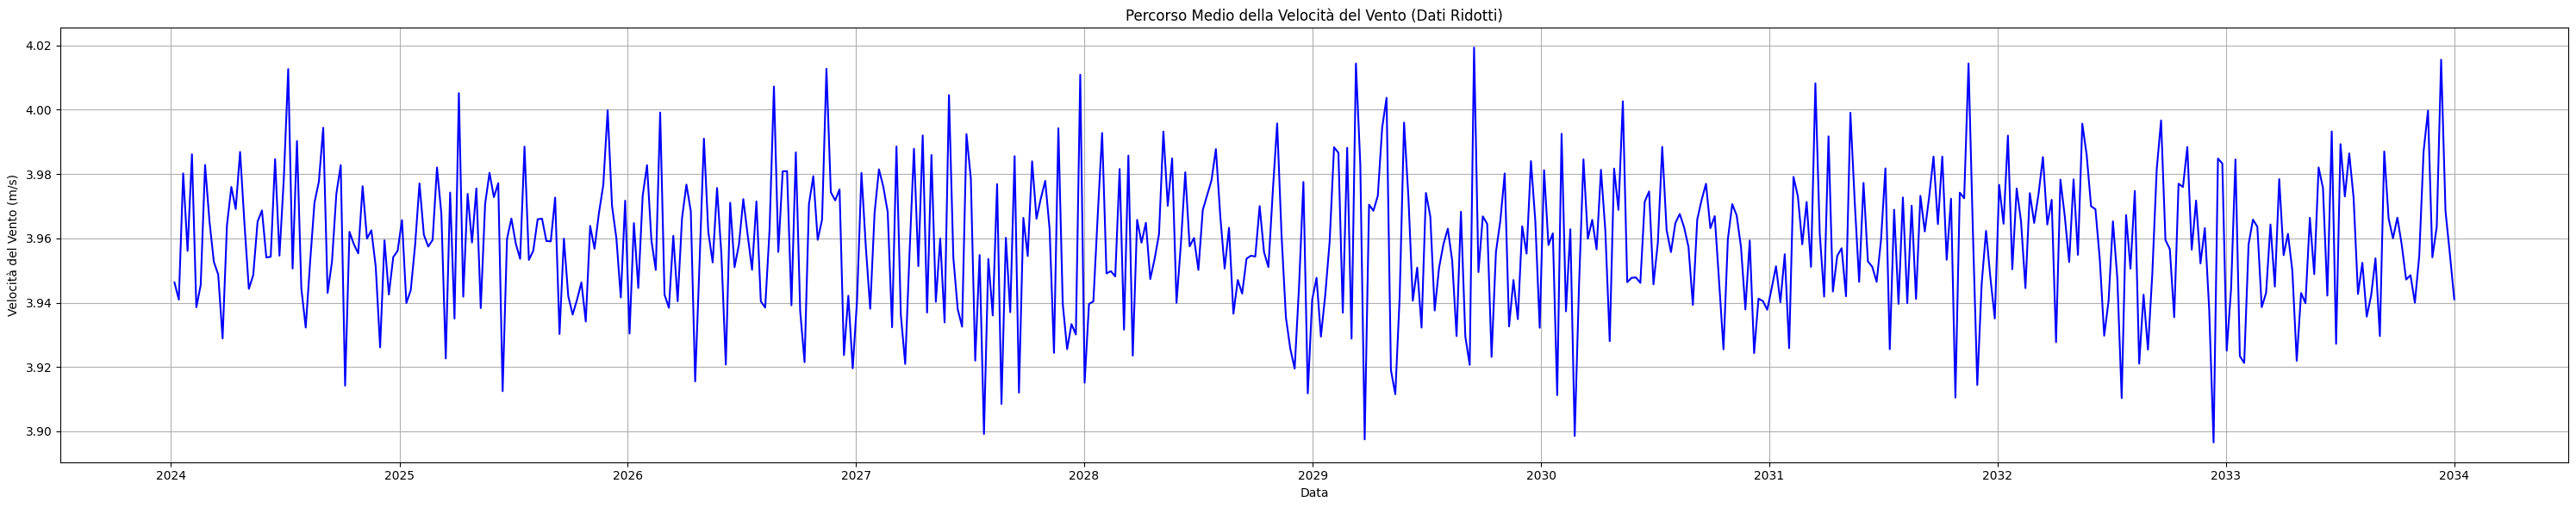

In [ ]:
percorso_medio_ridotto_df = percorso_medio_df.resample('1W').mean()

plt.figure(figsize=(30, 6))
plt.plot(percorso_medio_ridotto_df.index, percorso_medio_ridotto_df['Velocità Media del Vento'], color='blue')
plt.title('Percorso Medio della Velocità del Vento (Dati Ridotti)')
plt.xlabel('Data')
plt.ylabel('Velocità del Vento (m/s)')
plt.grid(True)
plt.tight_layout()
plt.show()


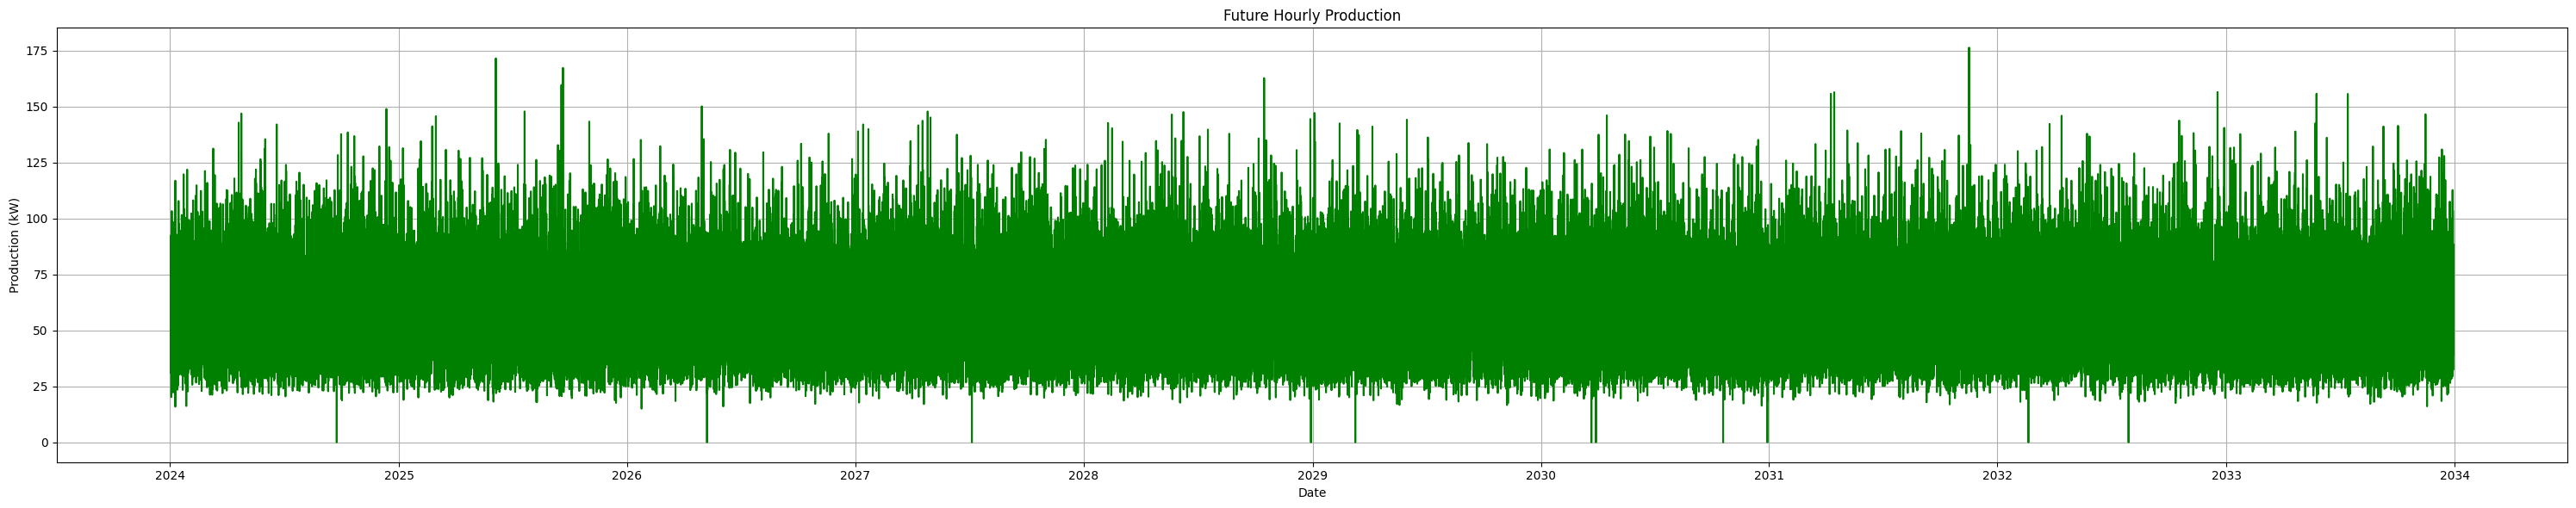

In [ ]:
# Prediction of future hourly production based on the average wind speed path
produzione_futura_oraria = percorso_medio_df['Velocità Media del Vento'].apply(calculate_power)

plt.figure(figsize=(30, 6))
plt.plot(produzione_futura_oraria.index, produzione_futura_oraria, color='green')
plt.title('Future Hourly Production')
plt.xlabel('Date')
plt.ylabel('Production (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df_copy = pd.DataFrame(produzione_futura_oraria)

In [ ]:
df_copy

,Velocità Media del Vento
2024-01-02 00:00:00+00:00,87.716544
2024-01-02 01:00:00+00:00,60.667418
2024-01-02 02:00:00+00:00,57.308729
2024-01-02 03:00:00+00:00,83.267674
2024-01-02 04:00:00+00:00,33.325906
...,...
2033-12-29 19:00:00+00:00,32.364505
2033-12-29 20:00:00+00:00,73.009835
2033-12-29 21:00:00+00:00,74.164996
2033-12-29 22:00:00+00:00,76.101060


In [ ]:
mean_betz = produzione_futura_oraria.mean()

# Variance
variance_betz = produzione_futura_oraria.var()

# Standard Deviation
std_deviation_betz = produzione_futura_oraria.std()

# Kurtosis
kurtosis_betz = produzione_futura_oraria.kurtosis()

# Skewness
skewness_betz = produzione_futura_oraria.skew()

stats_df = pd.DataFrame({
    'Mean': [mean_betz],
    'Variance': [variance_betz],
    'Standard deviation': [std_deviation_betz],
    'Kurtosis': [kurtosis_betz],
    'Skewness': [skewness_betz]
})

stats_df

,Mean,Variance,Standard deviation,Kurtosis,Skewness
0,61.368397,326.077687,18.057621,0.399458,0.344409


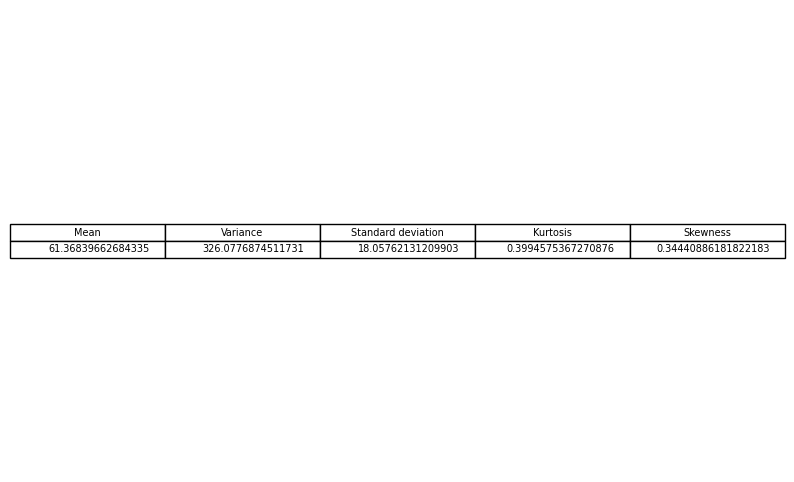

In [ ]:
plt.figure(figsize=(10, 6))
plt.table(cellText=stats_df.values,
          colLabels=stats_df.columns,
          loc='center')

plt.axis('off')

plt.savefig('stats_df.png', bbox_inches='tight', pad_inches=0.05)

plt.show()


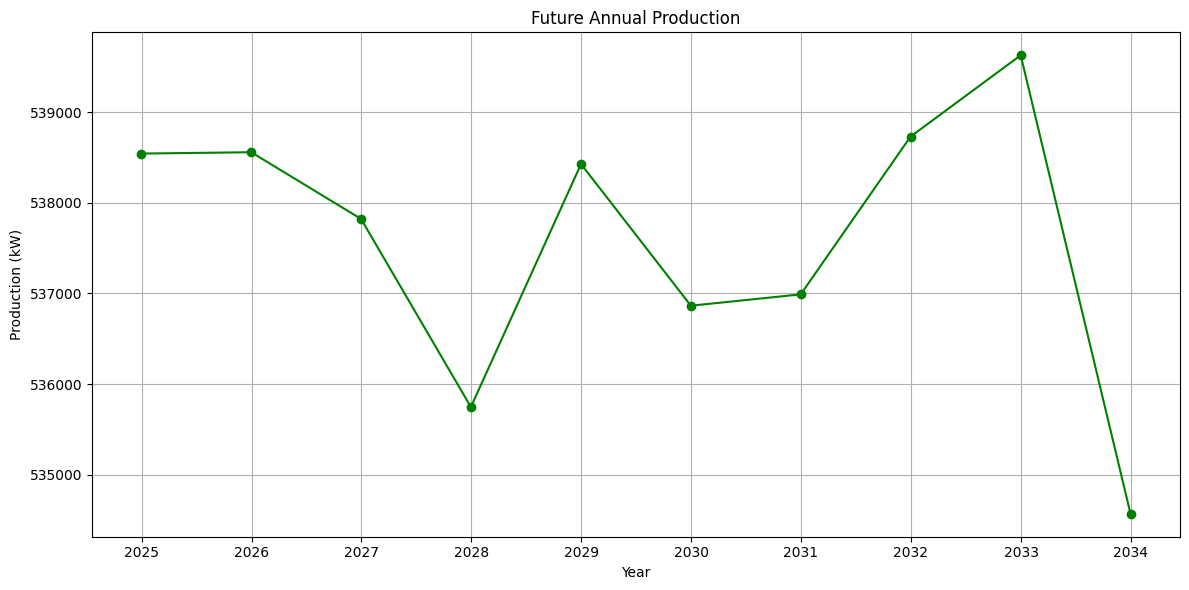

In [ ]:
produzione_futura_oraria = percorso_medio_df['Velocità Media del Vento'].apply(calculate_power)

produzione_futura_annuale = produzione_futura_oraria.resample('Y').sum()

plt.figure(figsize=(12, 6))
plt.plot(produzione_futura_annuale.index, produzione_futura_annuale, marker='o', linestyle='-', color='green')
plt.title('Future Annual Production')
plt.xlabel('Year')
plt.ylabel('Production (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()


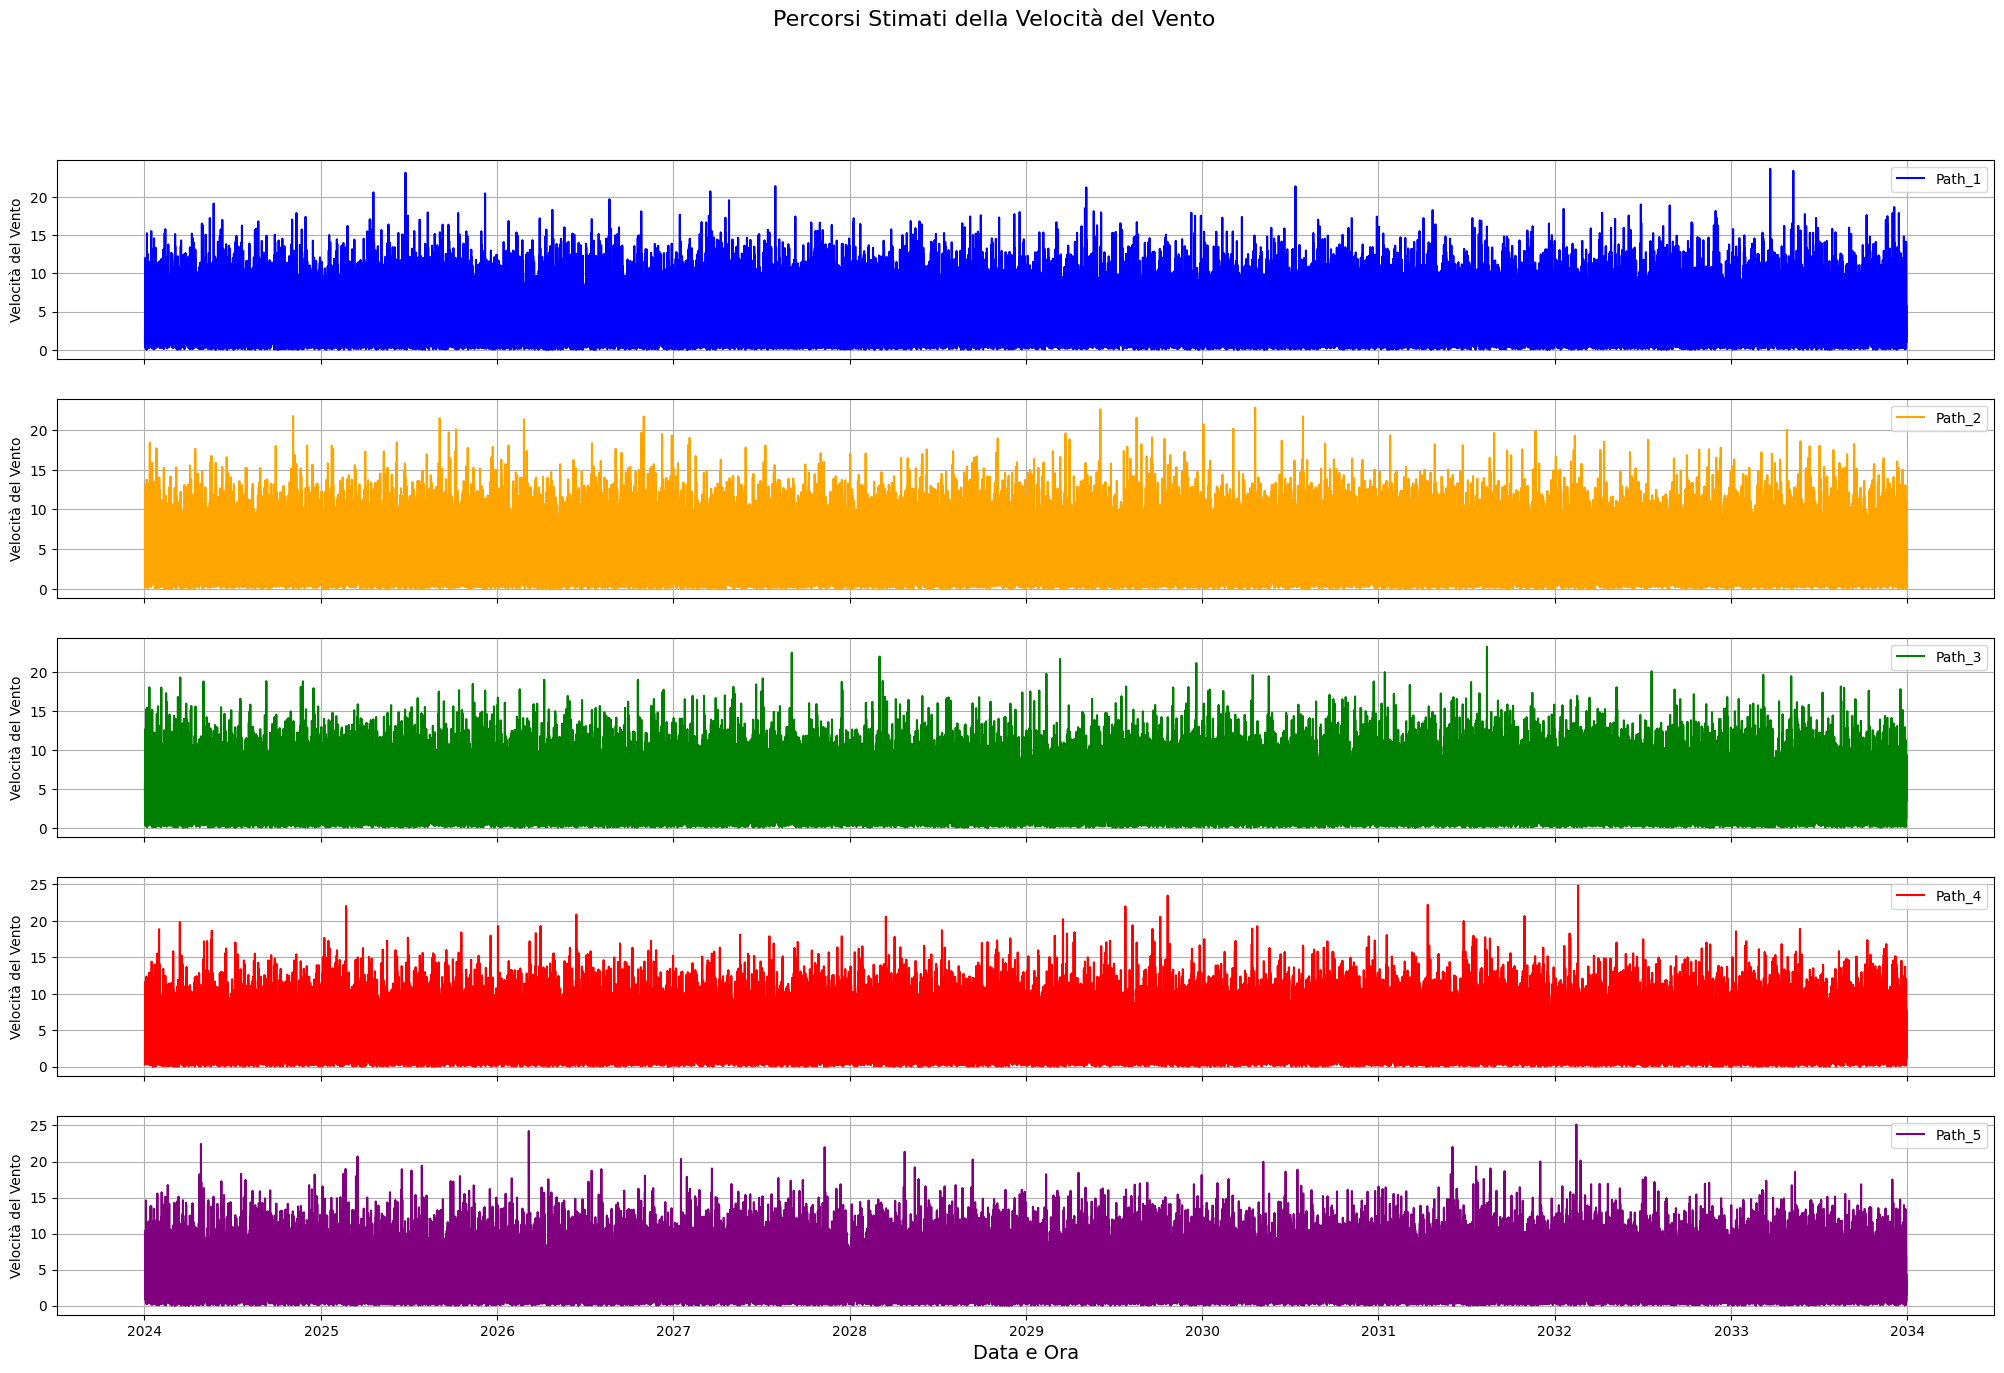

In [ ]:
percorsi_stimati = monte_carlo_df.iloc[:, :5]

colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, axs = plt.subplots(5, 1, figsize=(25, 15), sharex=True)

for i, colonna in enumerate(percorsi_stimati.columns):
    axs[i].plot(percorsi_stimati.index, percorsi_stimati[colonna], label=colonna, color=colors[i])
    axs[i].set_ylabel('Velocità del Vento')
    axs[i].legend()
    axs[i].grid(True)

plt.suptitle('Percorsi Stimati della Velocità del Vento', fontsize=16)
plt.xlabel('Data e Ora', fontsize=14)
plt.grid(True)
plt.show()


In [ ]:
monte_carlo_df

,Path_1,Path_2,Path_3,Path_4,Path_5,Path_6,Path_7,Path_8,Path_9,Path_10,...,Path_91,Path_92,Path_93,Path_94,Path_95,Path_96,Path_97,Path_98,Path_99,Path_100
2024-01-02 00:00:00+00:00,1.096011,6.285619,3.645475,3.284302,10.296046,4.976048,8.779634,4.273263,3.416659,9.603609,...,4.204050,1.718558,4.417158,5.936890,2.503623,3.215442,3.907595,6.006859,3.592939,4.472102
2024-01-02 01:00:00+00:00,5.708239,0.896042,5.879257,0.292680,5.673058,4.775870,2.903672,1.246417,4.313246,4.794802,...,3.646759,6.595541,0.968320,0.479038,4.025742,3.110840,1.981400,2.477533,6.007197,3.744915
2024-01-02 02:00:00+00:00,4.384249,3.127013,1.078242,1.391897,1.134455,3.301579,2.680113,4.778241,2.002705,5.359849,...,3.395455,2.682287,5.093830,3.934582,3.781492,2.351184,2.229715,7.206803,5.215853,3.057908
2024-01-02 03:00:00+00:00,2.117379,3.248657,1.299139,2.197124,4.215954,2.617612,9.762990,5.030935,5.547259,4.418837,...,6.254623,1.349154,1.511782,9.153057,3.024649,0.985535,3.432402,4.558777,5.780372,4.231353
2024-01-02 04:00:00+00:00,6.228240,5.562122,0.486172,11.624294,1.289626,0.786623,8.147783,6.197087,3.212513,10.442521,...,3.456035,2.062104,5.831092,7.729525,8.340770,5.541057,1.781227,2.000461,2.421028,0.872238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2033-12-29 19:00:00+00:00,2.501917,1.766843,7.331161,1.144641,0.620381,7.425182,0.381483,7.318332,3.415686,1.471145,...,4.633811,10.731025,5.808002,2.528503,0.901469,0.799266,4.951001,3.423279,1.964059,6.533009
2033-12-29 20:00:00+00:00,1.656557,6.836894,5.078708,2.792215,3.540947,0.299799,2.893176,1.261313,2.057687,0.543718,...,4.703386,2.914758,3.226361,1.503683,7.994046,2.090292,2.341054,8.568408,9.790583,2.572073
2033-12-29 21:00:00+00:00,2.654998,0.184776,6.105131,2.443620,3.077140,1.475082,0.418019,4.337629,1.425217,4.778743,...,1.281388,0.749906,2.944163,1.337898,2.568291,5.428519,6.624361,0.719242,6.954358,3.059055
2033-12-29 22:00:00+00:00,0.947260,6.158122,3.452857,7.885932,2.400627,2.818397,3.037148,2.253159,4.072583,3.461814,...,1.821869,3.694265,3.135826,2.974921,8.286923,1.174061,3.696150,1.795433,0.407604,1.998002
